## Definição e carregamento de bases de dados para Matching

Para a estimação do modelo, serão utilizadas as seguintes covariáveis:
-> Variáveis escolhidas e suas fontes:  
 * PIB per Capita (IBGE)
 * População (IBGE)
 * Participação Setorial no PIB (IBGE)
 * Educação média (RAIS)
 * Receita Corrente Municipal Bruta (IPEADATA)

 Obs: todos as base de dados são carregadas diretamente do repositório no github. No caso da RAIS, se desejar alterar os parâmetros de busca no database, o código está como comentário.


## Importação das bibliotecas utilizadas

In [1]:
# ================================================================
# IMPORTS
# ================================================================
import warnings
import requests
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import statsmodels.api as sm
from statsmodels.tools.sm_exceptions import PerfectSeparationWarning

from linearmodels.panel import PanelOLS
from sklearn.metrics import roc_auc_score

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=PerfectSeparationWarning)


## Carregamento de dados do IBGE via GitHub
* PIB per Capita
* População
* Participação dos setores econômicos

> **Fonte:** `pib_percapita_municipios.parquet` (GitHub Release — mvtp23/TCC).  
> As três bases originais (pib_per_capita, populacao, pib_setor) foram consolidadas
> neste único arquivo e carregadas a seguir.


In [2]:
URL_PIB = (
    "https://github.com/mvtp23/TCC/releases/download/"
    "database_ibge/pib_percapita_municipios.parquet"
)


In [3]:
# Baixar e ler o arquivo parquet diretamente do GitHub
# (o requests lida com o redirect do GitHub Releases)
_resp = requests.get(URL_PIB, headers={"User-Agent": "Mozilla/5.0"}, allow_redirects=True)
_resp.raise_for_status()
df_raw = pd.read_parquet(io.BytesIO(_resp.content))

print(f"Shape: {df_raw.shape}")
print(f"\nColunas: {df_raw.columns.tolist()}")
df_raw.head(3)


Shape: (77980, 15)

Colunas: ['cod_municipio', 'nome_municipio', 'sigla_uf', 'ano', 'pib_reais', 'populacao', 'pib_percapita_rs', 'vab_agro_reais', 'vab_ind_reais', 'vab_serv_reais', 'vab_adm_reais', 'part_agropecuaria', 'part_industria', 'part_servicos', 'part_adm_publica']


,cod_municipio,nome_municipio,sigla_uf,ano,pib_reais,populacao,pib_percapita_rs,vab_agro_reais,vab_ind_reais,vab_serv_reais,vab_adm_reais,part_agropecuaria,part_industria,part_servicos,part_adm_publica
0,1100015,Alta Floresta D'Oeste - RO,RO,2010,262077000.0,NaN,NaN,69260000.0,16119000.0,62496000.0,93245000.0,28.72,6.68,25.92,38.67
1,1100015,Alta Floresta D'Oeste - RO,RO,2011,280510000.0,24228.0,11577.926366,73328000.0,17942000.0,65486000.0,102539000.0,28.28,6.92,25.26,39.55
2,1100015,Alta Floresta D'Oeste - RO,RO,2012,329029000.0,24069.0,13670.239727,106125000.0,18906000.0,71330000.0,112789000.0,34.33,6.12,23.07,36.48


### Mapeamento de colunas

Ajuste o dicionário `MAPA_COLUNAS` caso os nomes das colunas no parquet
sejam diferentes dos nomes utilizados no restante do notebook.

| Chave (nome no .parquet) | Valor (nome interno do notebook) |
|---|---|
| `cod_municipio` | `cod_municipio` |
| `ano` | `ano` |
| `nome_municipio` | `nome_municipio` |
| `sigla_uf` | `sigla_uf` |
| `pib_per_capita` | `pib_per_capita` |
| `populacao` | `populacao` |
| `pib_total` | `pib_total` |
| `part_servicos` | `part_servicos` |
| `part_industria` | `part_industria` |
| `part_agropecuaria` | `part_agropecuaria` |
| `part_adm_publica` | `part_adm_publica` |


In [4]:
# Renomeie as chaves para os nomes reais do seu arquivo, se necessário
MAPA_COLUNAS = {
    "cod_municipio"    : "cod_municipio",
    "ano"              : "ano",
    "nome_municipio"   : "nome_municipio",
    "sigla_uf"         : "sigla_uf",
    "pib_per_capita"   : "pib_percapita_rs",
    "populacao"        : "populacao",
    "pib_total"        : "pib_REAIS",
    "part_servicos"    : "part_servicos",
    "part_industria"   : "part_industria",
    "part_agropecuaria": "part_agropecuaria",
    "part_adm_publica" : "part_adm_publica",
}

# Rename columns (usando MAPA_COLUNAS) e normalizar nomes esperados pelo notebook
df_pib = df_raw.rename(columns=MAPA_COLUNAS).copy()

# Normalizar possíveis variações de nomes para os nomes internos esperados
_normalize = {
    "pib_REAIS": "pib_total",
    "pib_reais": "pib_total",
    "pib_total": "pib_total",
    "pib_percapita_rs": "pib_per_capita",
    "pib_per_capita": "pib_per_capita",
}

df_pib = df_pib.rename(columns={k: v for k, v in _normalize.items() if k in df_pib.columns})

# Colunas finais desejadas (conformes ao restante do notebook)
colunas_desejadas = [
    "cod_municipio", "ano", "nome_municipio", "sigla_uf",
    "pib_per_capita", "populacao", "pib_total",
    "part_servicos", "part_industria", "part_agropecuaria", "part_adm_publica"
]

# Selecionar apenas colunas presentes e avisar sobre as faltantes
presentes = [c for c in colunas_desejadas if c in df_pib.columns]
faltantes = [c for c in colunas_desejadas if c not in df_pib.columns]
if faltantes:
    print("⚠️ Colunas faltantes após rename:", faltantes)

df_pib = df_pib[presentes].copy()

# Garantir tipos corretos nas chaves de join (padrão do notebook)
df_pib["cod_municipio"] = pd.to_numeric(df_pib["cod_municipio"], errors="coerce")
df_pib["ano"]           = pd.to_numeric(df_pib["ano"],           errors="coerce")
df_pib = df_pib.dropna(subset=["cod_municipio", "ano"])
df_pib["cod_municipio"] = df_pib["cod_municipio"].astype(int)
df_pib["ano"]           = df_pib["ano"].astype(int)

print(f"Shape após seleção: {df_pib.shape}")
df_pib.head(3)

Shape após seleção: (77980, 11)


,cod_municipio,ano,nome_municipio,sigla_uf,pib_per_capita,populacao,pib_total,part_servicos,part_industria,part_agropecuaria,part_adm_publica
0,1100015,2010,Alta Floresta D'Oeste - RO,RO,NaN,NaN,262077000.0,25.92,6.68,28.72,38.67
1,1100015,2011,Alta Floresta D'Oeste - RO,RO,11577.926366,24228.0,280510000.0,25.26,6.92,28.28,39.55
2,1100015,2012,Alta Floresta D'Oeste - RO,RO,13670.239727,24069.0,329029000.0,23.07,6.12,34.33,36.48


In [5]:
# --- Verificação 1: número de dígitos do código de município ---
n_digitos = df_pib["cod_municipio"].astype(str).str.len().value_counts()
print("Dígitos em cod_municipio:")
print(n_digitos)
if n_digitos.index[0] != 7:
    print("\n⚠️  ATENÇÃO: o notebook usa 7 dígitos; verifique o código de município")
else:
    print("\n✅ Formato compatível com o notebook (7 dígitos)")

# --- Verificação 2: cobertura temporal ---
anos = sorted(df_pib["ano"].unique())
print(f"\nPeríodo disponível: {anos[0]} a {anos[-1]}")
faltando = [a for a in range(2010, 2022) if a not in anos]
if faltando:
    print(f"⚠️  Anos do período de análise faltando: {faltando}")
else:
    print("✅ Cobertura temporal suficiente para o período de análise (2010-2021)")

# --- Verificação 3: duplicatas por chave ---
n_dup = df_pib.duplicated(subset=["cod_municipio", "ano"]).sum()
print(f"\n{'✅' if n_dup == 0 else '⚠️ '} Duplicatas (cod_municipio, ano): {n_dup}")

Dígitos em cod_municipio:
cod_municipio
7    77980
Name: count, dtype: int64

✅ Formato compatível com o notebook (7 dígitos)

Período disponível: 2010 a 2023
✅ Cobertura temporal suficiente para o período de análise (2010-2021)

✅ Duplicatas (cod_municipio, ano): 0


In [6]:
# Detectar se as participações estão em % (0-100) ou proporção (0-1)
cols_part = ["part_servicos", "part_industria", "part_agropecuaria", "part_adm_publica"]
if df_pib[cols_part].max().max() > 1:
    df_pib[cols_part] = df_pib[cols_part] / 100
    print("Participações convertidas de % para proporção")
else:
    print("Participações já em proporção — sem conversão")

# pib_servicos = pib_total × part_servicos
df_pib["pib_servicos"] = df_pib["pib_total"] * df_pib["part_servicos"]

# pib_servicos_per_capita = pib_servicos / populacao
df_pib["pib_servicos_per_capita"] = df_pib["pib_servicos"] / df_pib["populacao"]

Participações convertidas de % para proporção


In [7]:
df_ibge = (
    df_pib[[
        "ano", "cod_municipio", "nome_municipio", "sigla_uf",
        "pib_per_capita", "populacao", "pib_servicos", "pib_servicos_per_capita",
        "part_servicos", "part_industria", "part_agropecuaria", "part_adm_publica"
    ]]
    .copy()
    .sort_values(["cod_municipio", "ano"])
    .reset_index(drop=True)
)

print(f"df_ibge: {df_ibge.shape[0]:,} linhas, {df_ibge['cod_municipio'].nunique():,} municípios")
df_ibge

df_ibge: 77,980 linhas, 5,570 municípios


,ano,cod_municipio,nome_municipio,sigla_uf,pib_per_capita,populacao,pib_servicos,pib_servicos_per_capita,part_servicos,part_industria,part_agropecuaria,part_adm_publica
0,2010,1100015,Alta Floresta D'Oeste - RO,RO,NaN,NaN,6.793036e+07,NaN,0.2592,0.0668,0.2872,0.3867
1,2011,1100015,Alta Floresta D'Oeste - RO,RO,11577.926366,24228.0,7.085683e+07,2924.584200,0.2526,0.0692,0.2828,0.3955
2,2012,1100015,Alta Floresta D'Oeste - RO,RO,13670.239727,24069.0,7.590699e+07,3153.724305,0.2307,0.0612,0.3433,0.3648
3,2013,1100015,Alta Floresta D'Oeste - RO,RO,13266.674440,25728.0,7.679812e+07,2985.001749,0.2250,0.0627,0.3416,0.3708
4,2014,1100015,Alta Floresta D'Oeste - RO,RO,14727.857477,25652.0,9.233408e+07,3599.488367,0.2444,0.0614,0.3419,0.3523
...,...,...,...,...,...,...,...,...,...,...,...,...
77975,2019,5300108,Brasília - DF,DF,90742.750230,3015268.0,1.410752e+11,46786.962019,0.5156,0.0389,0.0041,0.4414
77976,2020,5300108,Brasília - DF,DF,87016.159932,3055149.0,1.288828e+11,42185.434335,0.4848,0.0455,0.0068,0.4629
77977,2021,5300108,Brasília - DF,DF,92732.270204,3094325.0,1.425537e+11,46069.391838,0.4968,0.0398,0.0089,0.4545
77978,2022,5300108,Brasília - DF,DF,116700.426034,2817381.0,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Logs
df_ibge['log_pib_per_capita']          = np.log(df_ibge['pib_per_capita'])
df_ibge['log_populacao']               = np.log(df_ibge['populacao'])
df_ibge['log_pib_servicos']            = np.log(df_ibge['pib_servicos'])
df_ibge['log_pib_servicos_per_capita'] = np.log(df_ibge['pib_servicos_per_capita'])

df_ibge = df_ibge.drop(columns=[
    'pib_per_capita', 'populacao', 'pib_servicos', 'pib_servicos_per_capita'
])

# Crescimento anual por município
# diff() dentro do grupo evita herdar o último valor do município anterior
df_ibge = df_ibge.sort_values(['cod_municipio', 'ano'])

df_ibge['%_pib_per_capita'] = (
    df_ibge
    .groupby('cod_municipio')['log_pib_per_capita']
    .diff()
    .pipe(lambda s: np.exp(s) - 1)
)

df_ibge['%_pib_servicos_per_capita'] = (
    df_ibge
    .groupby('cod_municipio')['log_pib_servicos_per_capita']
    .diff()
    .pipe(lambda s: np.exp(s) - 1)
)

df_ibge

c:\Users\joohn\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\joohn\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\joohn\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,ano,cod_municipio,nome_municipio,sigla_uf,part_servicos,part_industria,part_agropecuaria,part_adm_publica,log_pib_per_capita,log_populacao,log_pib_servicos,log_pib_servicos_per_capita,%_pib_per_capita,%_pib_servicos_per_capita
0,2010,1100015,Alta Floresta D'Oeste - RO,RO,0.2592,0.0668,0.2872,0.3867,NaN,NaN,18.033994,NaN,NaN,NaN
1,2011,1100015,Alta Floresta D'Oeste - RO,RO,0.2526,0.0692,0.2828,0.3955,9.356856,10.095264,18.076172,7.980908,NaN,NaN
2,2012,1100015,Alta Floresta D'Oeste - RO,RO,0.2307,0.0612,0.3433,0.3648,9.522976,10.088680,18.145019,8.056339,0.180716,0.078350
3,2013,1100015,Alta Floresta D'Oeste - RO,RO,0.2250,0.0627,0.3416,0.3708,9.493010,10.155335,18.156691,8.001356,-0.029521,-0.053499
4,2014,1100015,Alta Floresta D'Oeste - RO,RO,0.2444,0.0614,0.3419,0.3523,9.597496,10.152377,18.340924,8.188547,0.110139,0.205858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77975,2019,5300108,Brasília - DF,DF,0.5156,0.0389,0.0041,0.4414,11.415784,14.919199,25.672559,10.753360,0.059319,0.085639
77976,2020,5300108,Brasília - DF,DF,0.4848,0.0455,0.0068,0.4629,11.373849,14.932339,25.582169,10.649830,-0.041068,-0.098351
77977,2021,5300108,Brasília - DF,DF,0.4968,0.0398,0.0089,0.4545,11.437472,14.945080,25.682984,10.737904,0.065690,0.092069
77978,2022,5300108,Brasília - DF,DF,NaN,NaN,NaN,NaN,11.667365,14.851318,NaN,NaN,0.258466,NaN


## Carregamento de dados via IPEA Data  


In [9]:
df_recorrm = pd.read_parquet("https://github.com/mvtp23/TCC/releases/download/database_ipead/receita_municipal_2010_2023.parquet")

In [10]:
df_recorrm.head(10)

,CODE,RAW DATE,TERCODIGO,YEAR,NIVNOME,VALUE (R$)
DATE,,,,,,
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4301073,2010,Municípios,8963643.63
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4316972,2010,Municípios,9470921.93
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,5107578,2010,Municípios,11842374.62
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4321469,2010,Municípios,8907258.61
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4302220,2010,Municípios,10880054.90
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4319364,2010,Municípios,6958895.94
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4315958,2010,Municípios,8534927.46
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4300471,2010,Municípios,8656572.40
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4314134,2010,Municípios,7866364.68


In [11]:
codigos_municipios = pd.read_excel("https://github.com/mvtp23/TCC/releases/download/database_ibge/Codigos.Municipios.IBGE.xlsx", header=1)
codigos_municipios = codigos_municipios[["Nome_Município","Código Município Completo"]]

In [12]:

mapa_municipios_nomes = (
    codigos_municipios
    .set_index("Código Município Completo")["Nome_Município"]
    .to_dict()
)

In [13]:

# ---------------------------------------------------------------
# 4. Limpeza e adição do nome do município
# ---------------------------------------------------------------

df_receita_mun = (
    df_recorrm
    .copy()
    .reset_index()
    .rename(columns={
        "TERCODIGO" : "cod_municipio",
        "YEAR"      : "ano",
        "VALUE (R$)": "receita_corrente_municipal",   # ajuste se a unidade vier diferente
    })
)



In [14]:
# Garantir tipo numérico no código para o merge
df_receita_mun["cod_municipio"] = pd.to_numeric(
    df_receita_mun["cod_municipio"], errors="coerce"
)

df_receita_mun["municipio"] = df_receita_mun["cod_municipio"].map(mapa_municipios_nomes)
df_receita_mun["log_receita_municipal"]= np.log(df_receita_mun["receita_corrente_municipal"])
df_receita_mun.drop(columns="receita_corrente_municipal", inplace = True)

# Reordenar colunas
df_receita_mun = df_receita_mun[["cod_municipio", "municipio", "ano", "log_receita_municipal"]]


c:\Users\joohn\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [15]:
df_receita_mun[np.isinf(df_receita_mun["log_receita_municipal"])]

,cod_municipio,municipio,ano,log_receita_municipal
17778,2610301,Paranatama,2013,-inf
17780,2603603,Camutanga,2013,-inf
18706,3523701,Itirapuã,2013,-inf
21662,3530706,Mogi Guaçu,2014,-inf
22072,4102802,Bela Vista do Paraíso,2014,-inf
22799,1600212,Cutias,2014,-inf
23082,3137908,Lamim,2014,-inf
23266,3301702,Duque de Caxias,2014,-inf
24605,4312427,Mormaço,2014,-inf
24606,4322152,Tunas,2014,-inf


In [16]:
mun_invalidos = df_receita_mun.loc[
    ~np.isfinite(df_receita_mun["log_receita_municipal"]),
    "cod_municipio"
].unique()

df_receita_mun = df_receita_mun[
    ~df_receita_mun["cod_municipio"].isin(mun_invalidos)
]

## Carregamento de dados RAIS

* Escolaridade média por município

In [17]:
#id_projeto = "prop-459900"

In [18]:
#dicionario_rais = "SELECT * FROM `basedosdados.br_me_rais.dicionario`"

In [19]:
#dicionario_rais= bd.read_sql(query=dicionario_rais, billing_project_id=id_projeto)

In [20]:
#dicionario_rais.to_parquet("dicionario_rais.parquet")

In [21]:
dicionario_rais = pd.read_parquet("https://github.com/mvtp23/TCC/releases/download/database_rais/dicionario_rais.parquet")

In [22]:
"""
query_rais =
SELECT
    ano,
    id_municipio,
    sigla_uf,
    AVG(valor_remuneracao_media) AS media_remuneracao,
    AVG(SAFE_CAST(grau_instrucao_apos_2005 AS INT64)) AS media_grau_instrucao
FROM `basedosdados.br_me_rais.microdados_vinculos`
WHERE ano BETWEEN 2014 AND 2024
AND vinculo_ativo_3112 = '1'
AND valor_remuneracao_media IS NOT NULL
GROUP BY ano, id_municipio, sigla_uf
"""


"\nquery_rais =\nSELECT\n    ano,\n    id_municipio,\n    sigla_uf,\n    AVG(valor_remuneracao_media) AS media_remuneracao,\n    AVG(SAFE_CAST(grau_instrucao_apos_2005 AS INT64)) AS media_grau_instrucao\nFROM `basedosdados.br_me_rais.microdados_vinculos`\nWHERE ano BETWEEN 2014 AND 2024\nAND vinculo_ativo_3112 = '1'\nAND valor_remuneracao_media IS NOT NULL\nGROUP BY ano, id_municipio, sigla_uf\n"

In [23]:
#rais = bd.read_sql(query=query_rais, billing_project_id=id_projeto)

In [24]:
rais = pd.read_parquet("https://github.com/mvtp23/TCC/releases/download/database_rais/rais.parquet")

In [25]:
rais.head(10)

,ano,id_municipio,sigla_uf,media_remuneracao,media_grau_instrucao
0,2014,1200385,AC,1298.782420,6.380491
1,2015,1600204,AP,1526.431580,6.520833
2,2018,5300108,DF,5205.375480,7.309029
3,2015,1200450,AC,1482.683027,6.346425
4,2015,1200302,AC,1414.295658,5.937701
5,2017,5300108,DF,4985.813913,7.173146
6,2022,1200104,AC,2369.228676,6.932105
7,2020,1400100,RR,3355.947724,7.497132
8,2015,1400605,RR,1194.314525,7.094923
9,2015,1400159,RR,1484.684438,6.764706


In [26]:
rais["id_municipio"] = pd.to_numeric(rais["id_municipio"], errors="coerce")

Tradução dos dados RAIS através de dicionário de dados

In [27]:
# Criação do mapa para faixa_etaria
mapa_faixa_etaria = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'faixa_etaria']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)

# Criação do mapa para sexo
mapa_sexo = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'sexo']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)


mapa_subsetor_ibge = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'subsetor_ibge']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)

mapa_grau_instrucao = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'grau_instrucao_apos_2005']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)


In [28]:
rais_tratada = rais.copy()
rais_tratada.sort_values(by=['ano'], inplace=True)


In [29]:
rais_tratada['log_escolaridade'] = np.log(rais_tratada['media_grau_instrucao'])
rais_tratada = rais_tratada[["ano", "id_municipio", "sigla_uf", "log_escolaridade"]]


In [30]:

rais_tratada['municipio_trabalho'] = rais_tratada['id_municipio'].map(mapa_municipios_nomes)

display(rais_tratada)

,ano,id_municipio,sigla_uf,log_escolaridade,municipio_trabalho
50112,2014,4202131.0,SC,1.920923,Bela Vista do Toldo
50107,2014,4202875.0,SC,1.656426,Brunópolis
50106,2014,4217550.0,SC,1.837412,Serra Alta
50105,2014,4218251.0,SC,1.761184,Timbó Grande
38981,2014,4127858.0,PR,1.868349,Três Barras do Paraná
...,...,...,...,...,...
61260,2024,1715705.0,TO,1.902565,Palmeirante
61268,2024,1720259.0,TO,1.966441,São Salvador do Tocantins
148,2024,1400506.0,RR,1.829984,São João da Baliza
22,2024,1400407.0,RR,2.013812,Normandia


## União dos dataframes

In [31]:
# ================================================================
# Construção do df_combinado sem colunas duplicadas
# ================================================================

# --- Merge 1: rais_tratada + df_ibge ---
df_combinado = pd.merge(
    rais_tratada,
    df_ibge,
    left_on  = ["ano", "id_municipio"],
    right_on = ["ano", "cod_municipio"],
    how      = "inner",
)

df_combinado = df_combinado.drop(columns=[
    "cod_municipio",   # duplicata de id_municipio
    "sigla_uf_x",      # sigla_uf da rais — manter a do ibge
]).rename(columns={
    "sigla_uf_y" : "sigla_uf",
})

# --- Merge 2: + df_receita_mun ---
df_combinado = pd.merge(
    df_combinado,
    df_receita_mun.drop(columns=["municipio"]),
    left_on  = ["ano", "id_municipio"],
    right_on = ["ano", "cod_municipio"],
    how      = "inner",
)

df_combinado = df_combinado.drop(columns=["cod_municipio"])

# --- Selecionar e renomear colunas finais ---
df_combinado = df_combinado.loc[:, ~df_combinado.columns.duplicated()]

df_combinado = df_combinado.rename(columns={"municipio_trabalho": "municipio"})

df_combinado.head()

,ano,id_municipio,log_escolaridade,municipio,nome_municipio,sigla_uf,part_servicos,part_industria,part_agropecuaria,part_adm_publica,log_pib_per_capita,log_populacao,log_pib_servicos,log_pib_servicos_per_capita,%_pib_per_capita,%_pib_servicos_per_capita,log_receita_municipal
0,2014,4202131.0,1.920923,Bela Vista do Toldo,Bela Vista do Toldo - SC,SC,0.1655,0.0505,0.5960,0.1880,10.005971,8.735364,16.942552,8.207187,-0.054435,-0.194176,16.794479
1,2014,4202875.0,1.656426,Brunópolis,Brunópolis - SC,SC,0.2542,0.0449,0.4771,0.2238,10.017894,7.897296,16.545557,8.648260,0.199099,0.312144,16.382871
2,2014,4217550.0,1.837412,Serra Alta,Serra Alta - SC,SC,0.2966,0.1212,0.4123,0.1699,10.198858,8.106816,17.090303,8.983487,-0.183277,-0.390284,16.442983
3,2014,4218251.0,1.761184,Timbó Grande,Timbó Grande - SC,SC,0.1935,0.3297,0.2737,0.2031,9.938406,8.931023,17.226951,8.295928,0.091885,0.177045,16.901637
4,2014,4127858.0,1.868349,Três Barras do Paraná,Três Barras do Paraná - PR,PR,0.2586,0.1029,0.4392,0.1992,9.924286,9.410174,17.981988,8.571813,-0.016851,0.018599,17.389673


In [32]:
df_combinado.columns

Index(['ano', 'id_municipio', 'log_escolaridade', 'municipio',
       'nome_municipio', 'sigla_uf', 'part_servicos', 'part_industria',
       'part_agropecuaria', 'part_adm_publica', 'log_pib_per_capita',
       'log_populacao', 'log_pib_servicos', 'log_pib_servicos_per_capita',
       '%_pib_per_capita', '%_pib_servicos_per_capita',
       'log_receita_municipal'],
      dtype='object')

In [33]:
df_combinado

,ano,id_municipio,log_escolaridade,municipio,nome_municipio,sigla_uf,part_servicos,part_industria,part_agropecuaria,part_adm_publica,log_pib_per_capita,log_populacao,log_pib_servicos,log_pib_servicos_per_capita,%_pib_per_capita,%_pib_servicos_per_capita,log_receita_municipal
0,2014,4202131.0,1.920923,Bela Vista do Toldo,Bela Vista do Toldo - SC,SC,0.1655,0.0505,0.5960,0.1880,10.005971,8.735364,16.942552,8.207187,-0.054435,-0.194176,16.794479
1,2014,4202875.0,1.656426,Brunópolis,Brunópolis - SC,SC,0.2542,0.0449,0.4771,0.2238,10.017894,7.897296,16.545557,8.648260,0.199099,0.312144,16.382871
2,2014,4217550.0,1.837412,Serra Alta,Serra Alta - SC,SC,0.2966,0.1212,0.4123,0.1699,10.198858,8.106816,17.090303,8.983487,-0.183277,-0.390284,16.442983
3,2014,4218251.0,1.761184,Timbó Grande,Timbó Grande - SC,SC,0.1935,0.3297,0.2737,0.2031,9.938406,8.931023,17.226951,8.295928,0.091885,0.177045,16.901637
4,2014,4127858.0,1.868349,Três Barras do Paraná,Três Barras do Paraná - PR,PR,0.2586,0.1029,0.4392,0.1992,9.924286,9.410174,17.981988,8.571813,-0.016851,0.018599,17.389673
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54846,2023,1200401.0,2.032702,Rio Branco,Rio Branco - AC,AC,NaN,NaN,NaN,NaN,10.478224,12.806984,NaN,NaN,0.150358,NaN,21.344457
54847,2023,1200252.0,1.935719,Epitaciolândia,Epitaciolândia - AC,AC,NaN,NaN,NaN,NaN,10.652550,9.839322,NaN,NaN,0.021315,NaN,18.142607
54848,2023,1200013.0,1.966021,Acrelândia,Acrelândia - AC,AC,NaN,NaN,NaN,NaN,10.487119,9.548311,NaN,NaN,0.127479,NaN,18.104230
54849,2023,1200351.0,1.970079,Marechal Thaumaturgo,Marechal Thaumaturgo - AC,AC,NaN,NaN,NaN,NaN,9.732203,9.746424,NaN,NaN,0.123066,NaN,18.234207


## Dados ANAC

Leitura da base de dados da ANAC disponível em: https://sistemas.anac.gov.br/dadosabertos/Voos%20e%20opera%C3%A7%C3%B5es%20a%C3%A9reas/Dados%20Estat%C3%ADsticos%20do%20Transporte%20A%C3%A9reo/

In [34]:
df_anac = pd.read_parquet("https://github.com/mvtp23/TCC/releases/download/database/dados_anac.parquet")

In [35]:
df_anac

,EMPRESA_SIGLA,EMPRESA_NOME,EMPRESA_NACIONALIDADE,ANO,MES,AEROPORTO_DE_ORIGEM_SIGLA,AEROPORTO_DE_ORIGEM_NOME,AEROPORTO_DE_ORIGEM_UF,AEROPORTO_DE_ORIGEM_REGIAO,AEROPORTO_DE_ORIGEM_PAIS,...,COMBUSTIVEL_LITROS,DISTANCIA_VOADA_KM,DECOLAGENS,CARGA_PAGA_KM,CARGA_GRATIS_KM,CORREIO_KM,ASSENTOS,PAYLOAD,HORAS_VOADAS,BAGAGEM_KG
0,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,None,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN
1,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KDFW,"DALLAS & FORT WORTH, TEXAS",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,247320.0,30.0,8.068897e+08,0.0,601812.0,6330.0,1050000.0,"409,08",NaN
2,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KJFK,"NEW YORK, NEW YORK",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,224141.0,29.0,3.715021e+08,0.0,62094786.0,6119.0,464000.0,"418,1",NaN
3,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KJFK,"NEW YORK, NEW YORK",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,222256.0,29.0,1.494457e+09,0.0,15174720.0,6119.0,1015000.0,"411,5",NaN
4,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KMIA,"MIAMI, FLORIDA",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1077232,USY,USC GMBH,ESTRANGEIRA,2026,1,MTCH,CAP-HAÏTIEN,None,None,HAITI,...,0.0,7144.0,2.0,0.000000e+00,0.0,0.0,408.0,34000.0,"9,667",0.0
1077233,USY,USC GMBH,ESTRANGEIRA,2026,1,SBFI,FOZ DO IGUAÇU,PR,SUL,BRASIL,...,0.0,2766.0,1.0,0.000000e+00,0.0,0.0,0.0,0.0,"4,333",0.0
1077234,USY,USC GMBH,ESTRANGEIRA,2026,1,SBFI,FOZ DO IGUAÇU,PR,SUL,BRASIL,...,0.0,2812.0,1.0,0.000000e+00,0.0,0.0,0.0,0.0,4,0.0
1077235,USY,USC GMBH,ESTRANGEIRA,2026,1,SPJC,"CALLAO/LIMA, LIMA METROPOLITAN AREA",None,None,PERU,...,0.0,3572.0,1.0,0.000000e+00,0.0,0.0,0.0,0.0,"4,833",0.0


In [36]:
df_anac.columns

Index(['EMPRESA_SIGLA', 'EMPRESA_NOME', 'EMPRESA_NACIONALIDADE', 'ANO', 'MES',
       'AEROPORTO_DE_ORIGEM_SIGLA', 'AEROPORTO_DE_ORIGEM_NOME',
       'AEROPORTO_DE_ORIGEM_UF', 'AEROPORTO_DE_ORIGEM_REGIAO',
       'AEROPORTO_DE_ORIGEM_PAIS', 'AEROPORTO_DE_ORIGEM_CONTINENTE',
       'AEROPORTO_DE_DESTINO_SIGLA', 'AEROPORTO_DE_DESTINO_NOME',
       'AEROPORTO_DE_DESTINO_UF', 'AEROPORTO_DE_DESTINO_REGIAO',
       'AEROPORTO_DE_DESTINO_PAIS', 'AEROPORTO_DE_DESTINO_CONTINENTE',
       'NATUREZA', 'GRUPO_DE_VOO', 'PASSAGEIROS_PAGOS', 'PASSAGEIROS_GRATIS',
       'CARGA_PAGA_KG', 'CARGA_GRATIS_KG', 'CORREIO_KG', 'ASK', 'RPK', 'ATK',
       'RTK', 'COMBUSTIVEL_LITROS', 'DISTANCIA_VOADA_KM', 'DECOLAGENS',
       'CARGA_PAGA_KM', 'CARGA_GRATIS_KM', 'CORREIO_KM', 'ASSENTOS', 'PAYLOAD',
       'HORAS_VOADAS', 'BAGAGEM_KG'],
      dtype='object')

In [37]:
df_anac["PASSAGEIROS_GRATIS"].fillna(0, inplace=True)
df_anac["PASSAGEIROS_PAGOS"].fillna(0, inplace=True)

In [38]:
df_anac["PASSAGEIROS_TOTAL"] = df_anac["PASSAGEIROS_PAGOS"] + df_anac["PASSAGEIROS_GRATIS"]

In [39]:
df_anac[["AEROPORTO_DE_ORIGEM_NOME", "AEROPORTO_DE_ORIGEM_SIGLA"]].drop_duplicates()

,AEROPORTO_DE_ORIGEM_NOME,AEROPORTO_DE_ORIGEM_SIGLA
0,None,None
1,"DALLAS & FORT WORTH, TEXAS",KDFW
2,"NEW YORK, NEW YORK",KJFK
4,"MIAMI, FLORIDA",KMIA
9,CONFINS,SBCF
...,...,...
1063522,ORAN,DAOO
1063789,"RIVERSIDE, CALIFORNIA",KRIV
1063948,"GUANTÁNAMO BAY, GUANTÁNAMO",MUGM
1069452,HYDERABAD,VOHY


In [40]:
df_anac["PASSAGEIROS_TOTAL"]

0           161.0
1          4074.0
2          2469.0
3          3019.0
4          1017.0
            ...  
1077232     109.0
1077233       0.0
1077234       0.0
1077235       0.0
1077236      57.0
Name: PASSAGEIROS_TOTAL, Length: 1077237, dtype: float64

In [41]:
# Cria um DataFrame com os dados de origem (passageiros embarcados)
df_origem = df_anac[[
    "ANO",
    "AEROPORTO_DE_ORIGEM_SIGLA",
    "AEROPORTO_DE_ORIGEM_NOME",
    "AEROPORTO_DE_ORIGEM_UF",          # sigla da UF
    "PASSAGEIROS_TOTAL"
]].rename(columns={
    "AEROPORTO_DE_ORIGEM_SIGLA": "AEROPORTO_SIGLA",
    "AEROPORTO_DE_ORIGEM_NOME": "AEROPORTO_NOME",
    "AEROPORTO_DE_ORIGEM_UF": "UF"
})

# Cria um DataFrame com os dados de destino (passageiros desembarcados)
df_destino = df_anac[[
    "ANO",
    "AEROPORTO_DE_DESTINO_SIGLA",
    "AEROPORTO_DE_DESTINO_NOME",
    "AEROPORTO_DE_DESTINO_UF",
    "PASSAGEIROS_TOTAL"
]].rename(columns={
    "AEROPORTO_DE_DESTINO_SIGLA": "AEROPORTO_SIGLA",
    "AEROPORTO_DE_DESTINO_NOME": "AEROPORTO_NOME",
    "AEROPORTO_DE_DESTINO_UF": "UF"
})

# Concatena os dois DataFrames
df_combined = pd.concat([df_origem, df_destino], ignore_index=True)

# Agrupa por ano, aeroporto (sigla e nome), UF e Estado, somando os passageiros
df_total_por_aeroporto = df_combined.groupby(
    ["ANO", "AEROPORTO_SIGLA", "AEROPORTO_NOME", "UF"],
    as_index=False
)["PASSAGEIROS_TOTAL"].sum()

# Ordena para melhor visualização
df_total_por_aeroporto = df_total_por_aeroporto.sort_values(
    ["ANO", "PASSAGEIROS_TOTAL"], ascending=[True, False]
)

# Exibe o resultado
print(df_total_por_aeroporto)

       ANO AEROPORTO_SIGLA  AEROPORTO_NOME  UF  PASSAGEIROS_TOTAL
44    2000            SBGR       GUARULHOS  SP         11917074.0
103   2000            SBSP       SÃO PAULO  SP         10588995.0
41    2000            SBGL  RIO DE JANEIRO  RJ          5163960.0
15    2000            SBBR        BRASÍLIA  DF          4925945.0
95    2000            SBRJ  RIO DE JANEIRO  RJ          4909664.0
...    ...             ...             ...  ..                ...
4699  2026            SBGP  GAVIÃO PEIXOTO  SP                0.0
4708  2026            SBJC           BELÉM  PA                0.0
4709  2026            SBJD         JUNDIAÍ  SP                0.0
4772  2026            SDCO        SOROCABA  SP                0.0
4775  2026            SDSC      SÃO CARLOS  SP                0.0

[4812 rows x 5 columns]


Filtro com o aeroportos com número de passageiros acima de 200 mil passageiros por ano (utilizou-se 2010)  
Classificação ANAC: https://www.gov.br/anac/pt-br/assuntos/regulados/aeroportos-e-aerodromos/seguranca-operacional-aerodromos/aerodromo-de-uso-publico-2013-classe-ii-iii-e-iv

In [42]:

aeroportos_2010_altos = df_total_por_aeroporto[
    (df_total_por_aeroporto["ANO"] == 2010) &
    (df_total_por_aeroporto["PASSAGEIROS_TOTAL"] > 200000)
]["AEROPORTO_SIGLA"].unique()

df_anac_filtrado = df_total_por_aeroporto[
    (df_total_por_aeroporto["AEROPORTO_SIGLA"].isin(aeroportos_2010_altos)) &
    (df_total_por_aeroporto["ANO"] >= 2010)
].copy()


In [43]:
df_anac_filtrado

,ANO,AEROPORTO_SIGLA,AEROPORTO_NOME,UF,PASSAGEIROS_TOTAL
2023,2010,SBGR,GUARULHOS,SP,26572475.0
2075,2010,SBSP,SÃO PAULO,SP,15470143.0
1993,2010,SBBR,BRASÍLIA,DF,14639022.0
2020,2010,SBGL,RIO DE JANEIRO,RJ,12240846.0
2077,2010,SBSV,SALVADOR,BA,8015891.0
...,...,...,...,...,...
4675,2026,SBBV,BOA VISTA,RR,30129.0
4720,2026,SBMA,MARABÁ,PA,25650.0
4706,2026,SBIZ,IMPERATRIZ,MA,25453.0
4690,2026,SBDN,PRESIDENTE PRUDENTE,SP,20519.0


In [44]:
df_anac_filtrado.groupby(['ANO', 'UF'])['AEROPORTO_SIGLA'].nunique().reset_index().sort_values(by='ANO', ascending=True)


,ANO,UF,AEROPORTO_SIGLA
0,2010,AC,1
1,2010,AL,1
2,2010,AM,1
3,2010,AP,1
4,2010,BA,3
...,...,...,...
449,2026,RS,1
450,2026,SC,4
451,2026,SE,1
452,2026,SP,6


Carregamento de dataframe com a distancia do município para o aeroporto mais próximo.  
O dataframe foi construído com base no código: https://github.com/mvtp23/TCC/blob/main/Distancia_Aeroporto.ipynb

In [45]:
df_distancia = pd.read_csv(r"https://github.com/mvtp23/TCC/releases/download/database/aeroporto_mais_proximo_por_municipio.csv", sep=',', encoding='utf-8')

In [46]:
df_distancia

,municipio,uf,codigo_ibge,latitude,longitude,aeroporto_mais_proximo,codigo_iata,codigo_icao,codigo_principal,distancia_km
0,Alta Floresta D'oeste,RO,1100015.0,-11.935540,-61.999824,Fazenda Kajussol Airport,\N,SJYD,\N,34.22
1,Ariquemes,RO,1100023.0,-9.908463,-63.033269,Ariquemes Airport,\N,SJOG,\N,3.15
2,Cabixi,RO,1100031.0,-13.499763,-60.544314,Brigadeiro Camarão Airport,BVH,SBVH,BVH,101.75
3,Cacoal,RO,1100049.0,-11.433865,-61.442944,Cacoal Airport,OAL,SSKW,OAL,6.96
4,Cerejeiras,RO,1100056.0,-13.195033,-60.818426,Brigadeiro Camarão Airport,BVH,SBVH,BVH,95.86
...,...,...,...,...,...,...,...,...,...,...
5560,Vianópolis,GO,5222005.0,-16.742081,-48.513471,Base Aérea Airport,\N,SBAN,\N,74.59
5561,Vicentinópolis,GO,5222054.0,-17.732662,-49.807239,Francisco Vilela do Amaral Airport,ITR,SBIT,ITR,101.04
5562,Vila Boa,GO,5222203.0,-15.034889,-47.057361,Presidente Juscelino Kubistschek International...,BSB,SBBR,BSB,131.03
5563,Vila Propício,GO,5222302.0,-15.454635,-48.882422,Base Aérea Airport,\N,SBAN,\N,86.57


In [47]:
df_distancia[df_distancia["codigo_ibge"]== 3205309]

,municipio,uf,codigo_ibge,latitude,longitude,aeroporto_mais_proximo,codigo_iata,codigo_icao,codigo_principal,distancia_km
3173,Vitória,ES,3205309.0,-20.320154,-40.322209,Eurico de Aguiar Salles Airport,VIX,SBVT,VIX,7.85


Foram consideradas somente cidades com distância inferior a 50 km para o aeroporto mais próximo  
Valor escolhido conforme a metodologia de Volkhausen (2022) no estudo dos efeitos da liberalização do mercado de aviação na Europa  https://www.tandfonline.com/doi/full/10.1080/17421772.2025.2536845

In [48]:
# Valores únicos das siglas de aeroportos
icao_validos = df_anac_filtrado['AEROPORTO_SIGLA'].unique()

# Depois, filtre df_distancia para distância <= 50 e para codigo_icao estar em icao_validos
df_distancia_filtrado = df_distancia[
    (df_distancia['distancia_km'] <= 50) &
    (df_distancia['codigo_icao'].isin(icao_validos))
]

# Selecionar as colunas desejadas
df_distancia_filtrado = df_distancia_filtrado[["municipio","uf", "codigo_ibge", "aeroporto_mais_proximo", "codigo_icao","distancia_km"]]

In [49]:
df_distancia_filtrado

,municipio,uf,codigo_ibge,aeroporto_mais_proximo,codigo_icao,distancia_km
16,Porto Velho,RO,1100205.0,Governador Jorge Teixeira de Oliveira Airport,SBPV,10.23
31,Candeias Do Jamari,RO,1100809.0,Governador Jorge Teixeira de Oliveira Airport,SBPV,23.77
55,Bujari,AC,1200138.0,Plácido de Castro Airport,SBRB,8.02
66,Rio Branco,AC,1200401.0,Plácido de Castro Airport,SBRB,15.49
69,Senador Guiomard,AC,1200450.0,Plácido de Castro Airport,SBRB,35.38
...,...,...,...,...,...,...
5541,Senador Canedo,GO,5220454.0,Santa Genoveva Airport,SBGO,17.10
5548,Terezópolis De Goiás,GO,5221197.0,Santa Genoveva Airport,SBGO,21.87
5550,Trindade,GO,5221403.0,Santa Genoveva Airport,SBGO,28.71
5558,Valparaíso De Goiás,GO,5221858.0,Presidente Juscelino Kubistschek International...,SBBR,23.29


In [50]:
df_distancia_filtrado[df_distancia_filtrado["codigo_ibge"] == 4209102]

,municipio,uf,codigo_ibge,aeroporto_mais_proximo,codigo_icao,distancia_km
4446,Joinville,SC,4209102.0,Lauro Carneiro de Loyola Airport,SBJV,10.3


---
## Framework de Estimação por Cenários

Esta seção substitui o matching e o DiD manuais por um framework automatizado.
O código percorre todas as combinações de parâmetros definidas abaixo e
consolida os resultados em uma única tabela comparativa.

**Total de especificações:** 3 anos pré-tratamento × 2 anos fim × 2 variáveis = **12 cenários**

### ⚙️ Parâmetros dos cenários

**Edite apenas este bloco.**

In [73]:
# ================================================================
# PARAMETROS -- edite apenas aqui
# ================================================================

MUNICIPIO_TRATADO   = 4205407
K_CONTROLES         = 10
ANO_MATCHING_INICIO = 2013

COVARIAVEIS_MATCHING = [
    "%_pib_per_capita",
    "part_servicos",
    "log_populacao",
]

# Especificacoes DiD: (rotulo, lista de covariaveis)
# Os graficos usam sempre a ultima especificacao bem-sucedida
ESPECIFICACOES_DID = [
    ("Sem covariaveis",                             []),
    ("So log_populacao",                            ["log_populacao"]),
    ("So log_escolaridade",                         ["log_escolaridade"]),
    ("log_populacao + log_escolaridade",            ["log_populacao", "log_escolaridade"]),
    ("log_pop + log_escol + log_receita",           ["log_populacao", "log_escolaridade",
                                                     "log_receita_municipal"]),
]

# ----------------------------------------------------------------
# Secao A: PIB per capita
# ano_fim em [2021, 2023] para capturar horizonte curto e longo
# ----------------------------------------------------------------
CENARIOS_PIB = [
    # (var_dep,               ano_pre, ano_fim)
    ("log_pib_per_capita",    2017,    2021),
    ("log_pib_per_capita",    2017,    2023),
    ("log_pib_per_capita",    2018,    2021),
    ("log_pib_per_capita",    2018,    2023),
    ("log_pib_per_capita",    2019,    2021),
    ("log_pib_per_capita",    2019,    2023),
]

# ----------------------------------------------------------------
# Secao B: PIB de servicos per capita
# restrito a ano_fim=2021 (RAIS disponivel ate 2021)
# ----------------------------------------------------------------
CENARIOS_SERVICOS = [
    # (var_dep,                        ano_pre, ano_fim)
    ("log_pib_servicos_per_capita",    2017,    2021),
    ("log_pib_servicos_per_capita",    2018,    2021),
    ("log_pib_servicos_per_capita",    2019,    2021),
]

# Lista unificada usada pelo caliper de referencia
CENARIOS = CENARIOS_PIB + CENARIOS_SERVICOS
# Total: 9 cenarios x 5 especificacoes = 45 modelos


### Funções do framework

Cada função encapsula uma etapa do pipeline. O loop de cenários chama
essas funções em sequência sem duplicar código.

In [74]:
# linearmodels e instalado automaticamente no ambiente Colab.
# Se necessario: !pip install linearmodels


In [75]:
# -- 1. Preparar base de matching ----------------------------------------
def preparar_base(df_combinado, df_distancia_filtrado, municipio_tratado, ano_pre_tratamento):
    """Filtra municipios com aeroporto proximo e marca dummy de tratamento."""
    codigos_validos = df_distancia_filtrado["codigo_ibge"].unique()
    df = df_combinado[df_combinado["id_municipio"].isin(codigos_validos)].copy()
    df["tratamento"] = 0
    df.loc[
        (df["id_municipio"] == municipio_tratado) &
        (df["ano"] == ano_pre_tratamento),
        "tratamento"
    ] = 1
    return df


# -- 2. Construir covariaveis de matching (medias do periodo pre) ---------
def construir_covariaveis(df_matching, ano_inicio, ano_pre_tratamento, municipio_tratado):
    """Agrega covariaveis como medias no periodo [ano_inicio, ano_pre_tratamento]."""
    periodo = df_matching.query("@ano_inicio <= ano <= @ano_pre_tratamento")
    colunas_num = (
        df_matching.select_dtypes(include="number")
        .columns
        .difference(["tratamento", "ano", "id_municipio"])
        .tolist()
    )
    df_avg = (
        periodo
        .groupby(["id_municipio", "municipio"])[colunas_num]
        .mean()
        .reset_index()
    )
    df_avg["tratamento"] = 0
    df_avg.loc[df_avg["id_municipio"] == municipio_tratado, "tratamento"] = 1
    return df_avg


# -- 3. Estimar propensity score ------------------------------------------
def estimar_propensity_score(df_avg, covariaveis_matching):
    """Ajusta Logit e retorna df_avg com coluna propensity_score."""
    y = df_avg["tratamento"]
    x = sm.add_constant(df_avg[covariaveis_matching])
    res = sm.Logit(y, x).fit(maxiter=5000, disp=False)
    df_avg = df_avg.copy()
    df_avg["propensity_score"] = res.predict(x)
    return df_avg


# -- 4. Realizar matching (k vizinhos mais proximos com caliper) ----------
def realizar_matching(df_avg, municipio_tratado, k, caliper):
    """Seleciona os k controles mais proximos no propensity score,
    restrito a municipios com distancia <= caliper."""
    tratado    = df_avg[df_avg["tratamento"] == 1].copy()
    controles  = df_avg[df_avg["tratamento"] == 0].copy()
    ps_tratado = tratado["propensity_score"].iloc[0]
    controles["distancia_ps"] = abs(controles["propensity_score"] - ps_tratado)
    dentro_caliper = controles[controles["distancia_ps"] <= caliper]
    if dentro_caliper.empty:
        raise ValueError(
            f"Nenhum controle dentro do caliper={caliper:.4f} "
            f"(PS tratado={ps_tratado:.4f}). Considere aumentar o CALIPER."
        )
    grupo_controle = dentro_caliper.sort_values("distancia_ps").head(k)
    return tratado, grupo_controle


# -- 5. Construir amostra pareada para o DiD ------------------------------
def construir_amostra_did(
    df_matching, municipio_tratado, grupo_controle,
    ano_pre_tratamento, ano_inicio_did, ano_fim
):
    """Filtra painel ao grupo matching + intervalo; cria dummies post/tratado/did."""
    ids_did = grupo_controle["id_municipio"].tolist() + [municipio_tratado]
    ano_tratamento = ano_pre_tratamento + 1
    df_did = (
        df_matching
        .query("@ano_inicio_did <= ano <= @ano_fim")
        .loc[lambda d: d["id_municipio"].isin(ids_did)]
        .assign(
            post    = lambda d: (d["ano"] >= ano_tratamento).astype(int),
            tratado = lambda d: (d["id_municipio"] == municipio_tratado).astype(int),
            did     = lambda d: (
                (d["id_municipio"] == municipio_tratado).astype(int)
                * (d["ano"] >= ano_tratamento).astype(int)
            ),
        )
        .set_index(["id_municipio", "ano"])
    )
    return df_did, ano_tratamento


# -- 6. Estimar modelo DiD (TWFE) ----------------------------------------
def estimar_did(df_did, var_dep, covariaveis):
    """Estima PanelOLS TWFE com erros clusterizados. Retorna (resultado, df_est)."""
    regressores = ["did"] + covariaveis
    df_est = df_did[regressores + [var_dep]].dropna()
    res = PanelOLS(
        dependent      = df_est[var_dep],
        exog           = df_est[regressores],
        entity_effects = True,
        time_effects   = True,
    ).fit(cov_type="clustered", cluster_entity=True)
    return res, df_est


# -- 7. Grafico de tendencias paralelas -----------------------------------
def plot_tendencias(df_did, var_dep, ano_tratamento, n_controles,
                    coef, pval, titulo):
    sig        = "***" if pval<0.01 else "**" if pval<0.05 else "*" if pval<0.10 else "n.s."
    efeito_pct = (np.exp(coef) - 1) * 100
    df_plot    = df_did.reset_index()
    trat_s = df_plot[df_plot["tratado"]==1].groupby("ano")[var_dep].mean()
    ctrl_s = df_plot[df_plot["tratado"]==0].groupby("ano")[var_dep].mean()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(trat_s.index, trat_s.values, marker="o", lw=2,
            color="steelblue", label="Florianopolis (tratado)")
    ax.plot(ctrl_s.index, ctrl_s.values, marker="s", lw=2,
            ls="--", color="darkorange", label=f"Controles (n={n_controles})")
    ax.axvline(ano_tratamento-0.5, color="red", ls=":", lw=1.8,
               label=f"Tratamento ({ano_tratamento})")
    ax.axvspan(df_plot["ano"].min(), ano_tratamento-0.5,
               alpha=0.04, color="gray", label="Periodo pre")
    ax.text(0.98, 0.05,
            f"DiD = {coef:+.4f} ({efeito_pct:+.1f}%)\np = {pval:.3f}  {sig}",
            transform=ax.transAxes, fontsize=9, ha="right", va="bottom",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow",
                      edgecolor="gray", alpha=0.85))
    ax.set_title(titulo)
    ax.set_xlabel("Ano")
    ax.set_ylabel(var_dep)
    ax.legend(fontsize=8)
    ax.grid(axis="y", ls=":", alpha=0.5)
    plt.tight_layout()
    plt.show()


# -- 8. Grafico de event study --------------------------------------------
def plot_event_study(df_did, var_dep, ano_tratamento, titulo):
    """Dummies de evento x tratado; ano_tratamento-1 e o ano-base omitido.
    Retorna DataFrame com coef, se, p_valor, ic_low, ic_high e sig por ano."""
    df_es       = df_did.reset_index().copy()
    ano_base    = ano_tratamento - 1
    anos        = sorted(df_es["ano"].unique())
    anos_evento = [a for a in anos if a != ano_base]
    for a in anos_evento:
        df_es[f"ev_{a}"] = ((df_es["ano"]==a) & (df_es["tratado"]==1)).astype(int)
    cols_ev = [f"ev_{a}" for a in anos_evento]
    df_ev   = df_es.set_index(["id_municipio","ano"])[cols_ev+[var_dep]].dropna()
    try:
        res_ev = PanelOLS(
            dependent=df_ev[var_dep], exog=df_ev[cols_ev],
            entity_effects=True, time_effects=True,
        ).fit(cov_type="clustered", cluster_entity=True)
    except Exception:
        return None
    anos_full  = sorted(anos_evento + [ano_base])
    coefs_full, ses_full, pvals_full = [], [], []
    for a in anos_full:
        if a == ano_base:
            coefs_full.append(0.0); ses_full.append(0.0); pvals_full.append(np.nan)
        else:
            idx = anos_evento.index(a)
            coefs_full.append(float(res_ev.params[cols_ev[idx]]))
            ses_full.append(float(res_ev.std_errors[cols_ev[idx]]))
            pvals_full.append(float(res_ev.pvalues[cols_ev[idx]]))
    c = np.array(coefs_full); s = np.array(ses_full)
    df_evento = pd.DataFrame({
        "ano"       : anos_full,
        "coef"      : coefs_full,
        "se"        : ses_full,
        "p_valor"   : pvals_full,
        "ic_low"    : c - 1.96 * s,
        "ic_high"   : c + 1.96 * s,
        "ano_base"  : ano_base,
    }).assign(sig=lambda d: d["p_valor"].apply(
        lambda p: "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.10 else "n.s." if not np.isnan(p) else "(base)"
    ))
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.fill_between(anos_full, c-1.96*s, c+1.96*s,
                    alpha=0.2, color="steelblue", label="IC 95%")
    ax.plot(anos_full, c, marker="o", lw=2,
            color="steelblue", label="Coef. evento")
    ax.axvline(ano_tratamento-0.5, color="red", ls=":", lw=1.8,
               label=f"Tratamento ({ano_tratamento})")
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.scatter([ano_base], [0], color="red", s=80, zorder=5,
               label=f"Ano base ({ano_base})")
    ax.set_title(titulo)
    ax.set_xlabel("Ano")
    ax.set_ylabel("Coeficiente de evento")
    ax.legend(fontsize=8)
    ax.grid(axis="y", ls=":", alpha=0.5)
    plt.tight_layout()
    plt.show()
    return df_evento


# -- 9. Consolidar resultado de um modelo ---------------------------------
def consolidar_resultado(var_dep, ano_pre, ano_fim, cov_label,
                         grupo_controle, resultado_did):
    """Extrai metricas do resultado DiD."""
    coef  = float(resultado_did.params["did"])
    se    = float(resultado_did.std_errors["did"])
    tstat = float(resultado_did.tstats["did"])
    pval  = float(resultado_did.pvalues["did"])
    ci    = resultado_did.conf_int().loc["did"]
    sig   = "***" if pval<0.01 else "**" if pval<0.05 else "*" if pval<0.10 else "n.s."
    return {
        "var_dep"      : var_dep,
        "ano_pre"      : ano_pre,
        "ano_fim"      : ano_fim,
        "covariaveis"  : cov_label,
        "n_controles"  : len(grupo_controle),
        "n_obs"        : int(resultado_did.nobs),
        "coef_did"     : round(coef, 6),
        "erro_padrao"  : round(se, 6),
        "t_stat"       : round(tstat, 4),
        "p_valor"      : round(pval, 4),
        "ic_25"        : round(float(ci["lower"]), 6),
        "ic_975"       : round(float(ci["upper"]), 6),
        "efeito_pct"   : round((np.exp(coef)-1)*100, 2),
        "r2_within"    : round(resultado_did.rsquared, 4),
        "sig"          : sig,
    }


# -- 10. Sensibilidade do propensity score --------------------------------
def sensibilidade_ps(df_combinado, df_distancia_filtrado, municipio_tratado,
                     ano_matching_inicio, ano_pre_ref, covariaveis_matching):
    """
    Avalia robustez do matching em duas dimensoes:
    A) Sensibilidade ao multiplicador do caliper (0.2x a 2.0x sigma)
    B) Sensibilidade a especificacao das covariaveis do Logit

    Retorna: df_caliper, df_spec, roc_auc_base
    """
    df_m   = preparar_base(df_combinado, df_distancia_filtrado,
                           municipio_tratado, ano_pre_ref)
    df_avg = construir_covariaveis(df_m, ano_matching_inicio,
                                   ano_pre_ref, municipio_tratado)

    df_base  = estimar_propensity_score(df_avg, covariaveis_matching)
    sigma_ps = df_base["propensity_score"].std()
    ps_flp   = df_base.loc[
        df_base["id_municipio"] == municipio_tratado, "propensity_score"
    ].iloc[0]

    try:
        auc_base = roc_auc_score(df_base["tratamento"], df_base["propensity_score"])
    except Exception:
        auc_base = float("nan")

    def _smd_max(df_ps, grupo, covs):
        """Standardized Mean Difference maximo entre tratado e grupo controle."""
        trat_v = df_ps.loc[df_ps["id_municipio"] == municipio_tratado, covs].values
        ctrl_v = df_ps.loc[
            df_ps["id_municipio"].isin(grupo["id_municipio"]), covs
        ].mean().values
        std_p  = df_ps[covs].std().values
        std_p[std_p == 0] = 1  # evita divisao por zero
        return float(np.abs((trat_v - ctrl_v) / std_p).max())

    # A. Sensibilidade ao caliper
    controles_base = df_base[df_base["tratamento"] == 0].copy()
    controles_base["distancia_ps"] = abs(
        controles_base["propensity_score"] - ps_flp
    )
    linhas_caliper = []
    for mult in [0.2, 0.5, 1.0, 2.0]:
        cal = mult * sigma_ps
        dentro = controles_base[controles_base["distancia_ps"] <= cal]
        grupo  = dentro.sort_values("distancia_ps").head(K_CONTROLES)
        smd    = _smd_max(df_base, grupo, covariaveis_matching) if not grupo.empty else float("nan")
        linhas_caliper.append({
            "Mult. caliper" : f"{mult}xo",
            "Caliper"       : round(cal, 4),
            "N controles"   : len(grupo),
            "SMD max."      : round(smd, 3) if not np.isnan(smd) else "---",
            "Municipios"    : ", ".join(grupo["municipio"].tolist()) if not grupo.empty else "---",
        })
    df_caliper = pd.DataFrame(linhas_caliper).set_index("Mult. caliper")

    # B. Sensibilidade a especificacao do PS
    specs_ps = {
        "Base (pib + serv + pop)"  : covariaveis_matching,
        "Sem part_servicos"        : [c for c in covariaveis_matching if c != "part_servicos"],
        "Sem %_pib_per_capita"     : [c for c in covariaveis_matching if c != "%_pib_per_capita"],
        "+ log_escolaridade"       : covariaveis_matching + ["log_escolaridade"],
        "+ log_receita_municipal"  : covariaveis_matching + ["log_receita_municipal"],
    }
    caliper_b2 = 2.0 * sigma_ps
    linhas_spec = []
    for rotulo_ps, covs_ps in specs_ps.items():
        try:
            df_tmp = estimar_propensity_score(df_avg, covs_ps)
            _, grp = realizar_matching(df_tmp, municipio_tratado, K_CONTROLES, caliper_b2)
            smd    = _smd_max(df_tmp, grp, covs_ps)
            try:
                auc_sp = roc_auc_score(df_tmp["tratamento"], df_tmp["propensity_score"])
            except Exception:
                auc_sp = float("nan")
            nomes = grp["municipio"].tolist()
        except Exception as e:
            smd, auc_sp, nomes = float("nan"), float("nan"), [str(e)]
        linhas_spec.append({
            "Especificacao PS" : rotulo_ps,
            "ROC-AUC"         : round(auc_sp, 3) if not np.isnan(auc_sp) else "---",
            "N controles"     : len(nomes),
            "SMD max."        : round(smd, 3) if not np.isnan(smd) else "---",
            "Municipios"      : ", ".join(nomes),
        })
    df_spec = pd.DataFrame(linhas_spec).set_index("Especificacao PS")

    return df_caliper, df_spec, auc_base


print("Funcoes definidas")

Funcoes definidas


### Calculo automatico do caliper

Seguindo Rosenbaum & Rubin (1985), o caliper e definido como
$c \\times \\hat{\\sigma}_{PS}$, onde $\\hat{\\sigma}_{PS}$ e o desvio padrao
do propensity score estimado sobre todos os municipios (tratado + pool de controles).
O multiplicador padrao adotado e **2xsigma** — valor testado na analise de sensibilidade abaixo.
O calculo usa `ano_pre=2017` como referencia.


In [76]:
# Estimar propensity score de referencia (ano_pre=2017)
df_m_ref   = preparar_base(df_combinado, df_distancia_filtrado, MUNICIPIO_TRATADO, 2017)
df_avg_ref = construir_covariaveis(df_m_ref, ANO_MATCHING_INICIO, 2017, MUNICIPIO_TRATADO)
df_avg_ref = estimar_propensity_score(df_avg_ref, COVARIAVEIS_MATCHING)

sigma_ps = df_avg_ref["propensity_score"].std()
CALIPER  = 2 * sigma_ps

print(f"Desvio padrao do PS : {sigma_ps:.4f}")
print(f"Caliper adotado     : {CALIPER:.4f}")

ps_flp   = df_avg_ref.loc[df_avg_ref["id_municipio"] == MUNICIPIO_TRATADO, "propensity_score"].iloc[0]
n_dentro = (abs(df_avg_ref[df_avg_ref["tratamento"] == 0]["propensity_score"] - ps_flp) <= CALIPER).sum()
n_total  = (df_avg_ref["tratamento"] == 0).sum()

print(f"\nPS Florianopolis    : {ps_flp:.4f}")
print(f"Controles no pool   : {n_total}")
print(f"Dentro do caliper   : {n_dentro}  ({n_dentro/n_total*100:.1f}%)")
if n_dentro < K_CONTROLES:
    print(f"\n Apenas {n_dentro} controle(s) dentro do caliper -- "
          f"menor que K_CONTROLES={K_CONTROLES}. Considere aumentar o caliper.")

Desvio padrao do PS : 0.0124
Caliper adotado     : 0.0248

PS Florianopolis    : 0.0484
Controles no pool   : 542
Dentro do caliper   : 7  (1.3%)

 Apenas 7 controle(s) dentro do caliper -- menor que K_CONTROLES=10. Considere aumentar o caliper.


### Analise de Sensibilidade do Propensity Score

Avalia a robustez do matching em duas dimensoes:

- **Caliper:** impacto de diferentes multiplicadores (0.2x a 2.0x sigma) no tamanho e composicao do grupo controle.
- **Especificacao:** estabilidade do grupo controle ao variar as covariaveis usadas no Logit.

Referencia de balanceamento: SMD < 0.1 indica equilibrio adequado (Austin, 2011). https://pubmed.ncbi.nlm.nih.gov/21818162/


In [77]:
df_caliper, df_spec, ps_auc = sensibilidade_ps(
    df_combinado, df_distancia_filtrado,
    MUNICIPIO_TRATADO, ANO_MATCHING_INICIO,
    ano_pre_ref=2017,
    covariaveis_matching=COVARIAVEIS_MATCHING,
)

print("-- A. Sensibilidade ao caliper (especificacao base, K=K_CONTROLES) --")
display(df_caliper)
print("\n-- B. Sensibilidade a especificacao do PS (caliper=2xsigma, K=K_CONTROLES) --")
display(df_spec)


c:\Users\joohn\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


-- A. Sensibilidade ao caliper (especificacao base, K=K_CONTROLES) --


c:\Users\joohn\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


,Caliper,N controles,SMD max.,Municipios
Mult. caliper,,,,
0.2xo,0.0025,0,---,---
0.5xo,0.0062,2,1.431,"Salvador, Rio de Janeiro"
1.0xo,0.0124,4,1.182,"Salvador, Rio de Janeiro, Recife, Belo Horizonte"
2.0xo,0.0248,7,0.929,"Salvador, Rio de Janeiro, Recife, Belo Horizon..."



-- B. Sensibilidade a especificacao do PS (caliper=2xsigma, K=K_CONTROLES) --


,ROC-AUC,N controles,SMD max.,Municipios
Especificacao PS,,,,
Base (pib + serv + pop),0.993,7,0.929,"Salvador, Rio de Janeiro, Recife, Belo Horizon..."
Sem part_servicos,0.948,10,0.06,"Mauá, Vila Velha, Serra, Macapá, Niterói, São ..."
Sem %_pib_per_capita,0.993,8,0.613,"Rio de Janeiro, Salvador, Recife, Belo Horizon..."
+ log_escolaridade,---,1,---,Singular matrix
+ log_receita_municipal,0.991,6,0.848,"Recife, Fortaleza, Embu das Artes, Rio de Jane..."


### Execucao dos cenarios

O pipeline e executado em duas secoes independentes:

- **Secao A — PIB per capita:** 6 cenarios (3 anos de corte x 2 horizontes temporais)
- **Secao B — PIB de servicos per capita:** 3 cenarios (3 anos de corte, fim=2021)

Cada secao possui seu proprio loop, tabela consolidada e grafico de coeficientes.


---
## Secao A — PIB per capita

Estimacao do efeito sobre o PIB per capita municipal.
Sao testados 3 anos de corte pre-tratamento (2017, 2018 e 2019)
com dois horizontes temporais (fim=2021 e fim=2023).



######################################################################
  [PIB] Cenario 01/6 -- log_pib_per_capita | pre=2017 | trat.=2018 | fim=2021
######################################################################

  Propensity scores:
    Florianopolis (tratado)             PS=0.0484
    -------------------------------------------------------
    Salvador                            PS=0.0449  dist=0.0035
    Rio de Janeiro                      PS=0.0447  dist=0.0037
    Recife                              PS=0.0415  dist=0.0068
    Belo Horizonte                      PS=0.0392  dist=0.0092
    Fortaleza                           PS=0.0280  dist=0.0204
    Goiânia                             PS=0.0263  dist=0.0220
    São José do Rio Preto               PS=0.0723  dist=0.0240

  -- Resultados por especificacao --


,Ano trat.,Coef. DiD,EP,t,p,Sig.,Efeito (%),"IC 2,5%","IC 97,5%",R2,N obs.
Especificacao,,,,,,,,,,,
Sem covariaveis,2018,0.040799,0.017714,2.3032,0.0256,**,4.16,0.005183,0.076415,0.0501,64
So log_populacao,2018,0.022027,0.031703,0.6948,0.4906,n.s.,2.23,-0.041751,0.085804,0.0848,64
So log_escolaridade,2018,0.042892,0.016107,2.6629,0.0106,**,4.38,0.010488,0.075296,0.1862,64
log_populacao + log_escolaridade,2018,0.022172,0.030353,0.7305,0.4688,n.s.,2.24,-0.038926,0.083270,0.2287,64
log_pop + log_escol + log_receita,2018,0.020750,0.033120,0.6265,0.5341,n.s.,2.10,-0.045956,0.087457,0.2646,64


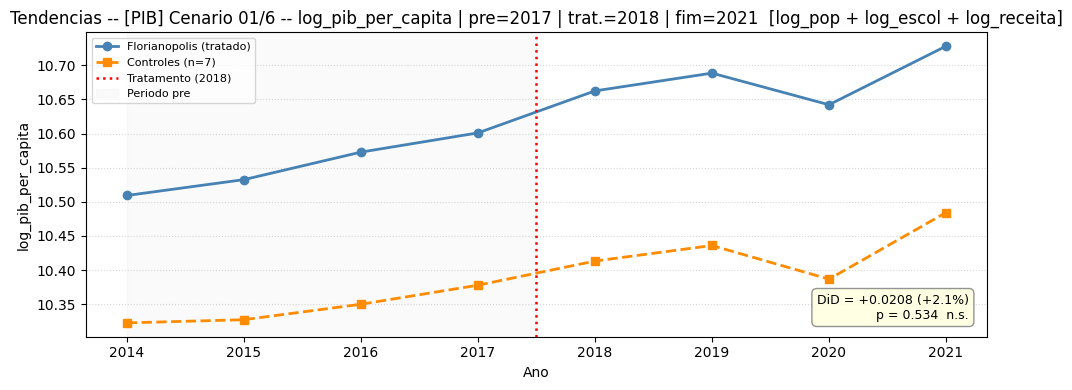

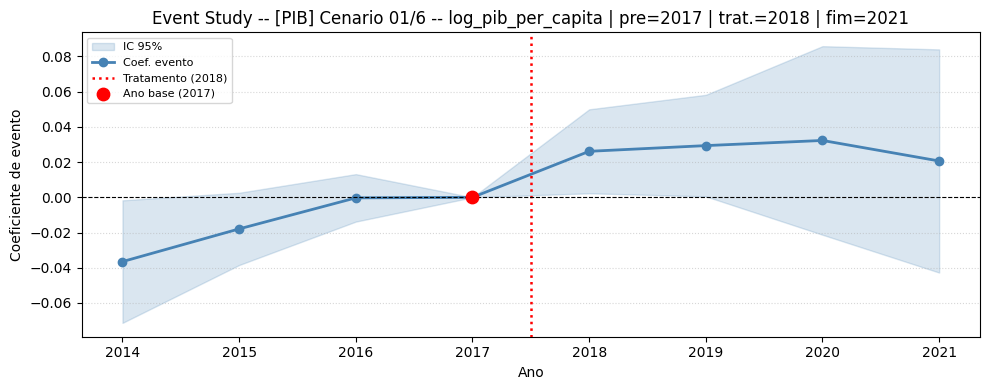


  -- Coeficientes do event study --


,Coef.,EP,p,"IC 2,5%","IC 97,5%",Sig.
Ano,,,,,,
2014,-0.0365,0.0178,0.0461,-0.0713,-0.0017,**
2015,-0.0179,0.0105,0.0944,-0.0384,0.0026,*
2016,-0.0003,0.0069,0.9661,-0.0138,0.0132,n.s.
2017,0.0000,0.0000,NaN,0.0000,0.0000,(base)
2018,0.0261,0.0122,0.0374,0.0023,0.0500,**
2019,0.0294,0.0147,0.0523,0.0006,0.0582,*
2020,0.0323,0.0273,0.2436,-0.0212,0.0859,n.s.
2021,0.0207,0.0323,0.5265,-0.0427,0.0840,n.s.



######################################################################
  [PIB] Cenario 02/6 -- log_pib_per_capita | pre=2017 | trat.=2018 | fim=2023
######################################################################

  Propensity scores:
    Florianopolis (tratado)             PS=0.0484
    -------------------------------------------------------
    Salvador                            PS=0.0449  dist=0.0035
    Rio de Janeiro                      PS=0.0447  dist=0.0037
    Recife                              PS=0.0415  dist=0.0068
    Belo Horizonte                      PS=0.0392  dist=0.0092
    Fortaleza                           PS=0.0280  dist=0.0204
    Goiânia                             PS=0.0263  dist=0.0220
    São José do Rio Preto               PS=0.0723  dist=0.0240

  -- Resultados por especificacao --


,Ano trat.,Coef. DiD,EP,t,p,Sig.,Efeito (%),"IC 2,5%","IC 97,5%",R2,N obs.
Especificacao,,,,,,,,,,,
Sem covariaveis,2018,0.013985,0.017823,0.7846,0.4357,n.s.,1.41,-0.021643,0.049613,0.0045,80
So log_populacao,2018,0.028949,0.025076,1.1544,0.2528,n.s.,2.94,-0.021194,0.079091,0.0315,80
So log_escolaridade,2018,0.006755,0.014815,0.4559,0.6501,n.s.,0.68,-0.022871,0.036380,0.0523,80
log_populacao + log_escolaridade,2018,0.024821,0.026677,0.9304,0.3559,n.s.,2.51,-0.028541,0.078184,0.0960,80
log_pop + log_escol + log_receita,2018,0.009676,0.026068,0.3712,0.7118,n.s.,0.97,-0.042486,0.061838,0.2452,80


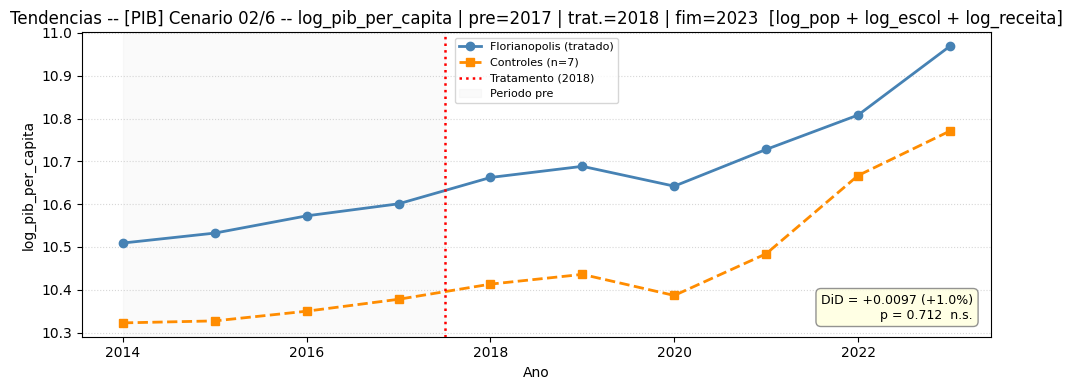

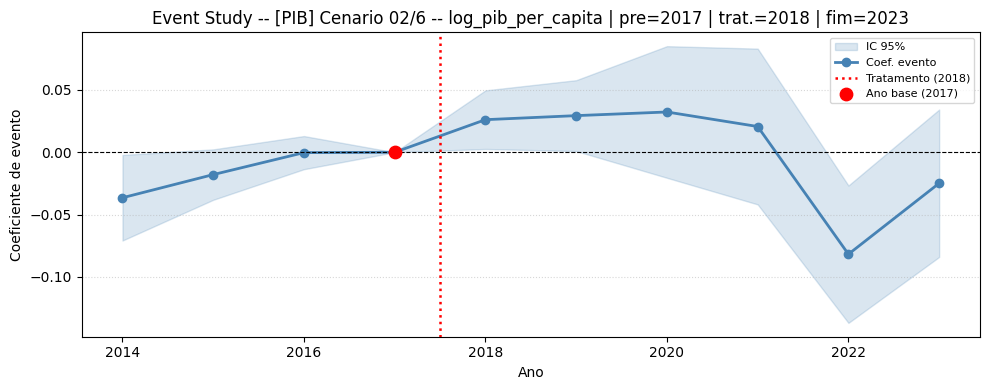


  -- Coeficientes do event study --


,Coef.,EP,p,"IC 2,5%","IC 97,5%",Sig.
Ano,,,,,,
2014,-0.0365,0.0175,0.0419,-0.0708,-0.0022,**
2015,-0.0179,0.0103,0.0884,-0.0382,0.0023,*
2016,-0.0003,0.0068,0.9655,-0.0136,0.0130,n.s.
2017,0.0000,0.0000,NaN,0.0000,0.0000,(base)
2018,0.0261,0.0120,0.0337,0.0026,0.0497,**
2019,0.0294,0.0145,0.0477,0.0010,0.0578,**
2020,0.0323,0.0269,0.2356,-0.0205,0.0851,n.s.
2021,0.0207,0.0319,0.5199,-0.0418,0.0831,n.s.
2022,-0.0818,0.0281,0.0053,-0.1369,-0.0267,***



######################################################################
  [PIB] Cenario 03/6 -- log_pib_per_capita | pre=2018 | trat.=2019 | fim=2021
######################################################################

  Propensity scores:
    Florianopolis (tratado)             PS=0.0485
    -------------------------------------------------------
    Salvador                            PS=0.0464  dist=0.0021
    Rio de Janeiro                      PS=0.0429  dist=0.0056
    Recife                              PS=0.0390  dist=0.0095
    Belo Horizonte                      PS=0.0380  dist=0.0105
    Fortaleza                           PS=0.0288  dist=0.0197
    São José do Rio Preto               PS=0.0700  dist=0.0215
    Goiânia                             PS=0.0258  dist=0.0227
    Embu das Artes                      PS=0.0250  dist=0.0235

  -- Resultados por especificacao --


,Ano trat.,Coef. DiD,EP,t,p,Sig.,Efeito (%),"IC 2,5%","IC 97,5%",R2,N obs.
Especificacao,,,,,,,,,,,
Sem covariaveis,2019,0.008290,0.032303,0.2566,0.7984,n.s.,0.83,-0.056447,0.073027,0.0006,72
So log_populacao,2019,-0.039955,0.062026,-0.6442,0.5222,n.s.,-3.92,-0.164311,0.084400,0.1010,72
So log_escolaridade,2019,0.013380,0.024570,0.5446,0.5883,n.s.,1.35,-0.035880,0.062640,0.0687,72
log_populacao + log_escolaridade,2019,-0.029453,0.042879,-0.6869,0.4952,n.s.,-2.90,-0.115457,0.056552,0.1403,72
log_pop + log_escol + log_receita,2019,-0.014940,0.038407,-0.3890,0.6989,n.s.,-1.48,-0.092009,0.062129,0.2753,72


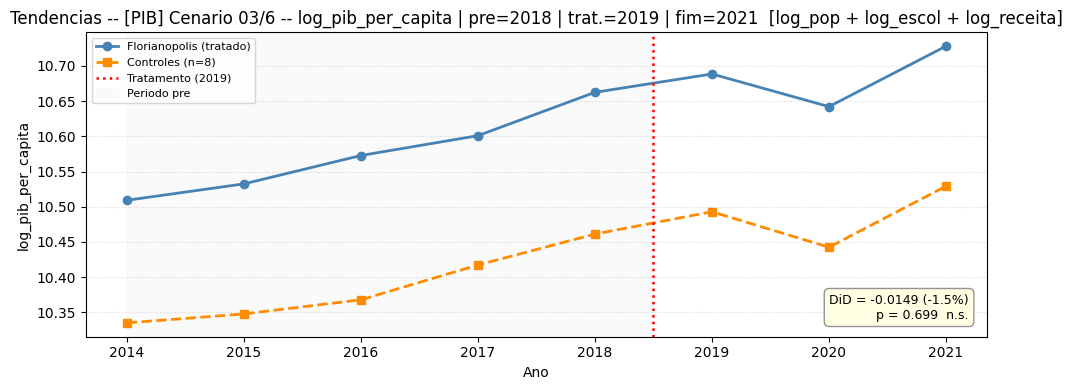

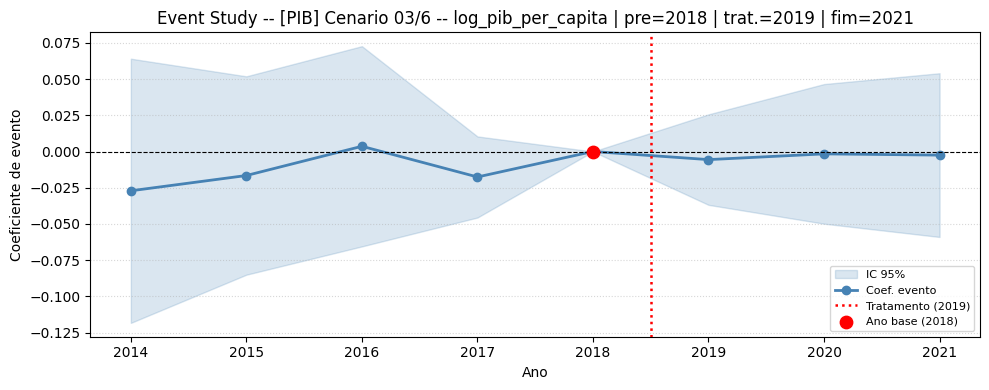


  -- Coeficientes do event study --


,Coef.,EP,p,"IC 2,5%","IC 97,5%",Sig.
Ano,,,,,,
2014,-0.0271,0.0465,0.5626,-0.1182,0.0640,n.s.
2015,-0.0166,0.0349,0.6374,-0.0850,0.0519,n.s.
2016,0.0036,0.0352,0.9190,-0.0655,0.0727,n.s.
2017,-0.0176,0.0143,0.2241,-0.0455,0.0104,n.s.
2018,0.0000,0.0000,NaN,0.0000,0.0000,(base)
2019,-0.0056,0.0159,0.7273,-0.0368,0.0256,n.s.
2020,-0.0016,0.0246,0.9472,-0.0498,0.0465,n.s.
2021,-0.0025,0.0288,0.9316,-0.0590,0.0540,n.s.



######################################################################
  [PIB] Cenario 04/6 -- log_pib_per_capita | pre=2018 | trat.=2019 | fim=2023
######################################################################

  Propensity scores:
    Florianopolis (tratado)             PS=0.0485
    -------------------------------------------------------
    Salvador                            PS=0.0464  dist=0.0021
    Rio de Janeiro                      PS=0.0429  dist=0.0056
    Recife                              PS=0.0390  dist=0.0095
    Belo Horizonte                      PS=0.0380  dist=0.0105
    Fortaleza                           PS=0.0288  dist=0.0197
    São José do Rio Preto               PS=0.0700  dist=0.0215
    Goiânia                             PS=0.0258  dist=0.0227
    Embu das Artes                      PS=0.0250  dist=0.0235

  -- Resultados por especificacao --


,Ano trat.,Coef. DiD,EP,t,p,Sig.,Efeito (%),"IC 2,5%","IC 97,5%",R2,N obs.
Especificacao,,,,,,,,,,,
Sem covariaveis,2019,-0.023069,0.030853,-0.7477,0.4571,n.s.,-2.28,-0.084588,0.038451,0.0051,90
So log_populacao,2019,-0.018659,0.039769,-0.4692,0.6404,n.s.,-1.85,-0.097976,0.060658,0.0060,90
So log_escolaridade,2019,-0.005579,0.020419,-0.2732,0.7855,n.s.,-0.56,-0.046303,0.035145,0.0626,90
log_populacao + log_escolaridade,2019,-0.004311,0.023315,-0.1849,0.8539,n.s.,-0.43,-0.050823,0.042201,0.0627,90
log_pop + log_escol + log_receita,2019,-0.015923,0.022977,-0.6930,0.4907,n.s.,-1.58,-0.061773,0.029928,0.3635,90


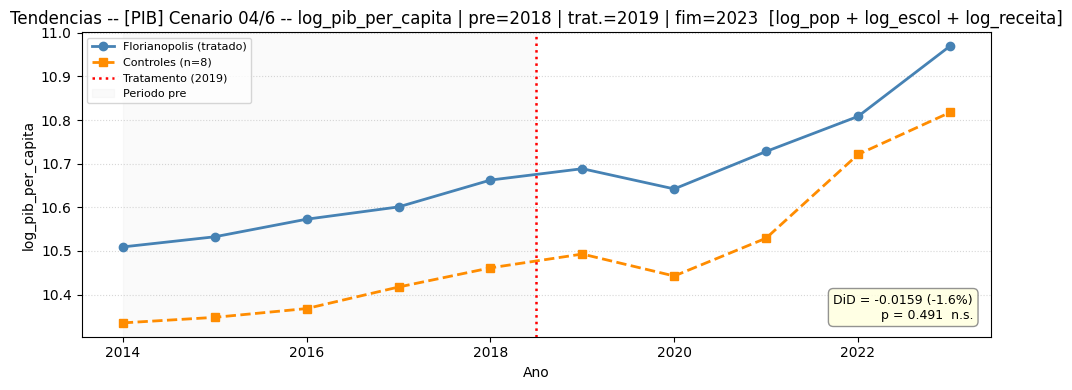

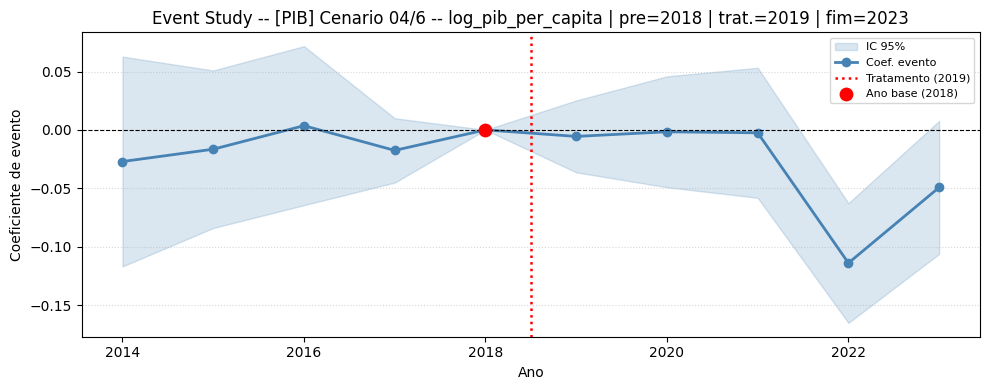


  -- Coeficientes do event study --


,Coef.,EP,p,"IC 2,5%","IC 97,5%",Sig.
Ano,,,,,,
2014,-0.0271,0.0458,0.5565,-0.1169,0.0627,n.s.
2015,-0.0166,0.0344,0.6322,-0.0840,0.0509,n.s.
2016,0.0036,0.0347,0.9178,-0.0645,0.0717,n.s.
2017,-0.0176,0.0141,0.2164,-0.0452,0.0100,n.s.
2018,0.0000,0.0000,NaN,0.0000,0.0000,(base)
2019,-0.0056,0.0157,0.7232,-0.0364,0.0252,n.s.
2020,-0.0016,0.0242,0.9464,-0.0491,0.0458,n.s.
2021,-0.0025,0.0284,0.9306,-0.0582,0.0532,n.s.
2022,-0.1140,0.0262,0.0000,-0.1653,-0.0627,***



######################################################################
  [PIB] Cenario 05/6 -- log_pib_per_capita | pre=2019 | trat.=2020 | fim=2021
######################################################################

  Propensity scores:
    Florianopolis (tratado)             PS=0.0488
    -------------------------------------------------------
    Salvador                            PS=0.0474  dist=0.0014
    Rio de Janeiro                      PS=0.0409  dist=0.0079
    Recife                              PS=0.0406  dist=0.0082
    Belo Horizonte                      PS=0.0384  dist=0.0104
    Fortaleza                           PS=0.0281  dist=0.0207
    Goiânia                             PS=0.0245  dist=0.0243

  -- Resultados por especificacao --


,Ano trat.,Coef. DiD,EP,t,p,Sig.,Efeito (%),"IC 2,5%","IC 97,5%",R2,N obs.
Especificacao,,,,,,,,,,,
Sem covariaveis,2020,0.040449,0.021927,1.8447,0.0723,*,4.13,-0.003833,0.084732,0.0493,56
So log_populacao,2020,0.027640,0.021573,1.2812,0.2075,n.s.,2.80,-0.015961,0.071241,0.0712,56
So log_escolaridade,2020,0.050838,0.018164,2.7989,0.0079,***,5.22,0.014128,0.087548,0.2742,56
log_populacao + log_escolaridade,2020,0.037068,0.016878,2.1963,0.0341,**,3.78,0.002929,0.071207,0.2999,56
log_pop + log_escol + log_receita,2020,0.042448,0.013970,3.0385,0.0043,***,4.34,0.014167,0.070729,0.3618,56


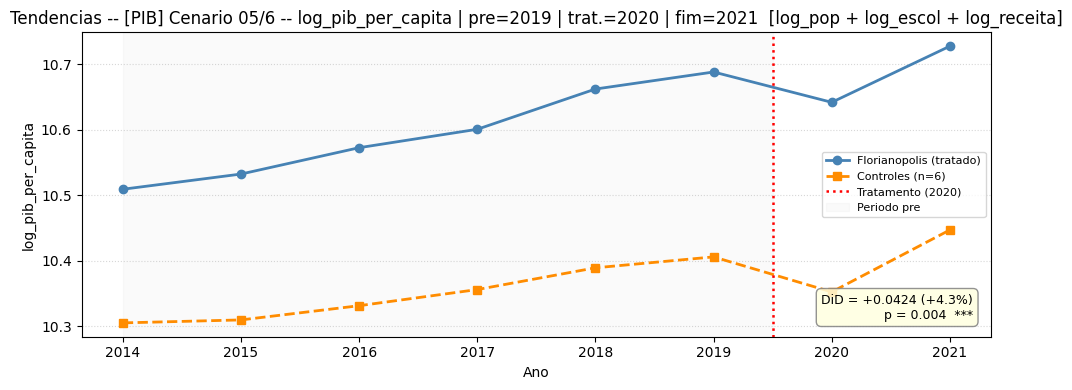

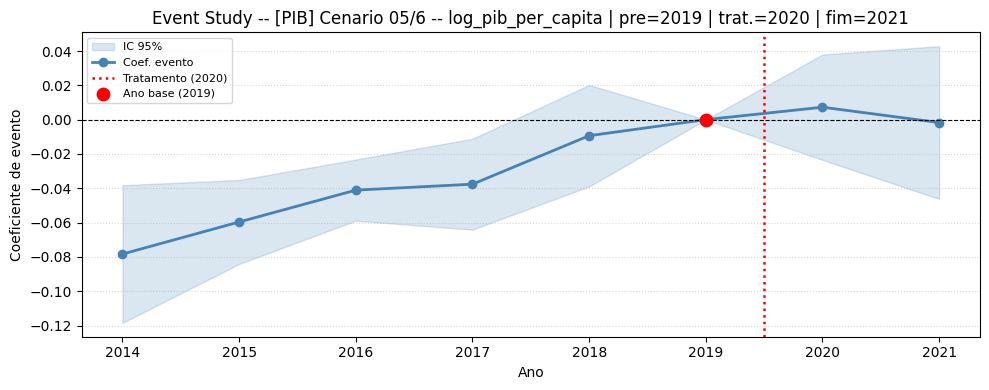


  -- Coeficientes do event study --


,Coef.,EP,p,"IC 2,5%","IC 97,5%",Sig.
Ano,,,,,,
2014,-0.0783,0.0205,0.0005,-0.1185,-0.0382,***
2015,-0.0596,0.0125,0.0000,-0.0841,-0.0352,***
2016,-0.0411,0.0091,0.0001,-0.0589,-0.0233,***
2017,-0.0376,0.0135,0.0086,-0.0641,-0.0111,***
2018,-0.0093,0.0151,0.5393,-0.0389,0.0202,n.s.
2019,0.0000,0.0000,NaN,0.0000,0.0000,(base)
2020,0.0073,0.0157,0.6465,-0.0235,0.0380,n.s.
2021,-0.0017,0.0227,0.9409,-0.0462,0.0428,n.s.



######################################################################
  [PIB] Cenario 06/6 -- log_pib_per_capita | pre=2019 | trat.=2020 | fim=2023
######################################################################

  Propensity scores:
    Florianopolis (tratado)             PS=0.0488
    -------------------------------------------------------
    Salvador                            PS=0.0474  dist=0.0014
    Rio de Janeiro                      PS=0.0409  dist=0.0079
    Recife                              PS=0.0406  dist=0.0082
    Belo Horizonte                      PS=0.0384  dist=0.0104
    Fortaleza                           PS=0.0281  dist=0.0207
    Goiânia                             PS=0.0245  dist=0.0243

  -- Resultados por especificacao --


,Ano trat.,Coef. DiD,EP,t,p,Sig.,Efeito (%),"IC 2,5%","IC 97,5%",R2,N obs.
Especificacao,,,,,,,,,,,
Sem covariaveis,2020,-0.005423,0.023131,-0.2345,0.8155,n.s.,-0.54,-0.051819,0.040972,0.0008,70
So log_populacao,2020,0.023142,0.039732,0.5825,0.5628,n.s.,2.34,-0.056585,0.102870,0.0407,70
So log_escolaridade,2020,-0.016507,0.018482,-0.8931,0.3759,n.s.,-1.64,-0.053594,0.020580,0.0708,70
log_populacao + log_escolaridade,2020,0.017844,0.038638,0.4618,0.6462,n.s.,1.80,-0.059726,0.095414,0.1330,70
log_pop + log_escol + log_receita,2020,0.016746,0.027466,0.6097,0.5448,n.s.,1.69,-0.038421,0.071912,0.3137,70


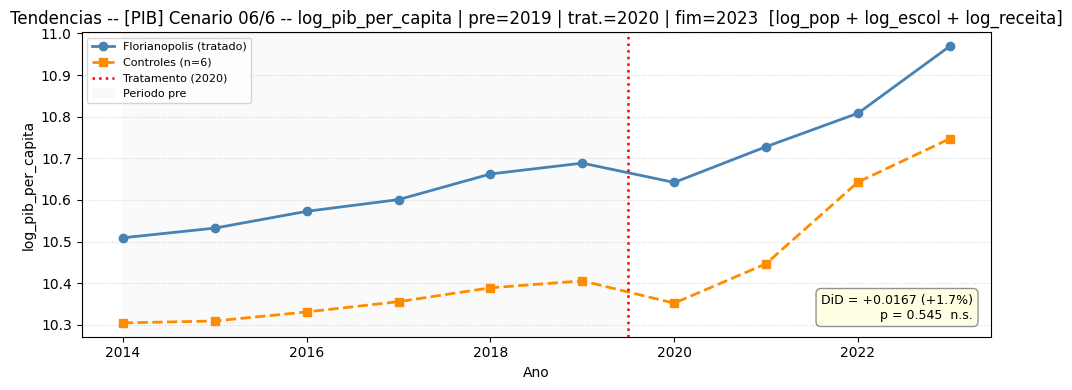

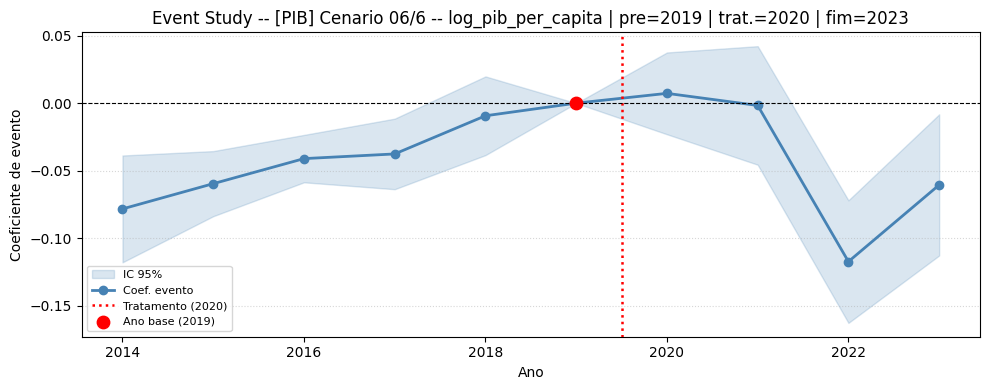


  -- Coeficientes do event study --


,Coef.,EP,p,"IC 2,5%","IC 97,5%",Sig.
Ano,,,,,,
2014,-0.0783,0.0202,0.0003,-0.1179,-0.0388,***
2015,-0.0596,0.0123,0.0000,-0.0838,-0.0355,***
2016,-0.0411,0.0090,0.0000,-0.0586,-0.0235,***
2017,-0.0376,0.0133,0.0071,-0.0637,-0.0115,***
2018,-0.0093,0.0149,0.5327,-0.0385,0.0198,n.s.
2019,0.0000,0.0000,NaN,0.0000,0.0000,(base)
2020,0.0073,0.0155,0.6412,-0.0230,0.0375,n.s.
2021,-0.0017,0.0224,0.9400,-0.0456,0.0422,n.s.
2022,-0.1174,0.0232,0.0000,-0.1628,-0.0720,***



Concluido [PIB] -- 30 modelos (6 cenarios x 5 especificacoes)


In [78]:
resultados_pib = []
total = len(CENARIOS_PIB)

for cenario, (var_dep, ano_pre, ano_fim) in enumerate(CENARIOS_PIB, start=1):

    ano_tratamento = ano_pre + 1
    rotulo = (
        f"[PIB] Cenario {cenario:02d}/{total} -- {var_dep} "
        f"| pre={ano_pre} | trat.={ano_tratamento} | fim={ano_fim}"
    )

    print(f"\n{'#'*70}")
    print(f"  {rotulo}")
    print(f"{'#'*70}")

    # -- 1-4: Matching ---------------------------------------------------
    df_m   = preparar_base(df_combinado, df_distancia_filtrado, MUNICIPIO_TRATADO, ano_pre)
    df_avg = construir_covariaveis(df_m, ANO_MATCHING_INICIO, ano_pre, MUNICIPIO_TRATADO)
    df_avg = estimar_propensity_score(df_avg, COVARIAVEIS_MATCHING)
    _, grupo_controle = realizar_matching(df_avg, MUNICIPIO_TRATADO, K_CONTROLES, CALIPER)

    ps_flp = df_avg.loc[df_avg["id_municipio"] == MUNICIPIO_TRATADO, "propensity_score"].iloc[0]
    print("\n  Propensity scores:")
    print(f"    {'Florianopolis (tratado)':<35} PS={ps_flp:.4f}")
    print(f"    {'-'*55}")
    for _, r in grupo_controle[["municipio", "propensity_score", "distancia_ps"]].iterrows():
        print(f"    {r['municipio']:<35} PS={r['propensity_score']:.4f}  dist={r['distancia_ps']:.4f}")

    # -- 5: Amostra DiD --------------------------------------------------
    df_did, _ = construir_amostra_did(
        df_m, MUNICIPIO_TRATADO, grupo_controle,
        ano_pre, ANO_MATCHING_INICIO, ano_fim
    )

    if var_dep not in df_did.columns:
        print(f"  {var_dep} ausente no painel -- cenario ignorado")
        continue

    # -- 6: Loop de especificacoes DiD -----------------------------------
    res_por_spec = {}

    for rotulo_spec, covs in ESPECIFICACOES_DID:
        try:
            res, _ = estimar_did(df_did, var_dep, covs)
            res_por_spec[rotulo_spec] = res
            resultados_pib.append(consolidar_resultado(
                var_dep, ano_pre, ano_fim, rotulo_spec, grupo_controle, res
            ))
        except Exception as e:
            print(f"  [{rotulo_spec}] Erro: {e}")

    # -- Tabela comparativa das especificacoes deste cenario -------------
    linhas_cen = [
        r for r in resultados_pib
        if r["var_dep"] == var_dep
        and r["ano_pre"] == ano_pre
        and r["ano_fim"] == ano_fim
    ]
    if linhas_cen:
        print("\n  -- Resultados por especificacao --")
        display(
            pd.DataFrame(linhas_cen)
            .rename(columns={
                "covariaveis" : "Especificacao",
                "ano_pre"     : "Ano pre",
                "coef_did"    : "Coef. DiD",
                "erro_padrao" : "EP",
                "t_stat"      : "t",
                "p_valor"     : "p",
                "efeito_pct"  : "Efeito (%)",
                "r2_within"   : "R2",
                "sig"         : "Sig.",
                "n_obs"       : "N obs.",
                "ic_25"       : "IC 2,5%",
                "ic_975"      : "IC 97,5%",
            })
            .assign(**{"Ano trat.": ano_tratamento})
            [["Ano trat.", "Especificacao", "Coef. DiD", "EP", "t", "p", "Sig.",
              "Efeito (%)", "IC 2,5%", "IC 97,5%", "R2", "N obs."]]
            .set_index("Especificacao")
        )

    # -- Graficos: usa ultima especificacao bem-sucedida -----------------
    rotulo_graf = [r for r, _ in ESPECIFICACOES_DID if r in res_por_spec]
    if rotulo_graf:
        res_graf = res_por_spec[rotulo_graf[-1]]
        coef_g   = float(res_graf.params["did"])
        pval_g   = float(res_graf.pvalues["did"])
        plot_tendencias(
            df_did, var_dep, ano_tratamento, len(grupo_controle),
            coef_g, pval_g,
            f"Tendencias -- {rotulo}  [{rotulo_graf[-1]}]"
        )
        df_evento = plot_event_study(
            df_did, var_dep, ano_tratamento,
            f"Event Study -- {rotulo}"
        )
        if df_evento is not None:
            print("\n  -- Coeficientes do event study --")
            display(
                df_evento
                .rename(columns={
                    "ano"     : "Ano",
                    "coef"    : "Coef.",
                    "se"      : "EP",
                    "p_valor" : "p",
                    "ic_low"  : "IC 2,5%",
                    "ic_high" : "IC 97,5%",
                    "sig"     : "Sig.",
                })
                .drop(columns=["ano_base"])
                .set_index("Ano")
                .round(4)
            )

print(f"\nConcluido [PIB] -- {len(resultados_pib)} modelos ({total} cenarios x {len(ESPECIFICACOES_DID)} especificacoes)")


#### Tabela consolidada — PIB per capita


In [79]:
df_resultados_pib = (
    pd.DataFrame(resultados_pib)
    .assign(**{"Ano trat.": lambda d: d["ano_pre"] + 1})
    .rename(columns={
        "var_dep"      : "Var. dependente",
        "ano_pre"      : "Ano pre",
        "ano_fim"      : "Ano fim",
        "covariaveis"  : "Covariaveis",
        "n_controles"  : "N contr.",
        "n_obs"        : "N obs.",
        "coef_did"     : "Coef. DiD",
        "erro_padrao"  : "EP",
        "t_stat"       : "t",
        "p_valor"      : "p-valor",
        "ic_25"        : "IC 2,5%",
        "ic_975"       : "IC 97,5%",
        "efeito_pct"   : "Efeito (%)",
        "r2_within"    : "R2 within",
        "sig"          : "Sig.",
    })
)

print("Secao A -- TWFE com EF municipio + ano. Erros clusterizados por municipio.")
print("      * p<0.10  ** p<0.05  *** p<0.01\n")
df_resultados_pib


Secao A -- TWFE com EF municipio + ano. Erros clusterizados por municipio.
      * p<0.10  ** p<0.05  *** p<0.01



,Var. dependente,Ano pre,Ano fim,Covariaveis,N contr.,N obs.,Coef. DiD,EP,t,p-valor,"IC 2,5%","IC 97,5%",Efeito (%),R2 within,Sig.,Ano trat.
0,log_pib_per_capita,2017,2021,Sem covariaveis,7,64,0.040799,0.017714,2.3032,0.0256,0.005183,0.076415,4.16,0.0501,**,2018
1,log_pib_per_capita,2017,2021,So log_populacao,7,64,0.022027,0.031703,0.6948,0.4906,-0.041751,0.085804,2.23,0.0848,n.s.,2018
2,log_pib_per_capita,2017,2021,So log_escolaridade,7,64,0.042892,0.016107,2.6629,0.0106,0.010488,0.075296,4.38,0.1862,**,2018
3,log_pib_per_capita,2017,2021,log_populacao + log_escolaridade,7,64,0.022172,0.030353,0.7305,0.4688,-0.038926,0.083270,2.24,0.2287,n.s.,2018
4,log_pib_per_capita,2017,2021,log_pop + log_escol + log_receita,7,64,0.020750,0.033120,0.6265,0.5341,-0.045956,0.087457,2.10,0.2646,n.s.,2018
5,log_pib_per_capita,2017,2023,Sem covariaveis,7,80,0.013985,0.017823,0.7846,0.4357,-0.021643,0.049613,1.41,0.0045,n.s.,2018
6,log_pib_per_capita,2017,2023,So log_populacao,7,80,0.028949,0.025076,1.1544,0.2528,-0.021194,0.079091,2.94,0.0315,n.s.,2018
7,log_pib_per_capita,2017,2023,So log_escolaridade,7,80,0.006755,0.014815,0.4559,0.6501,-0.022871,0.036380,0.68,0.0523,n.s.,2018
8,log_pib_per_capita,2017,2023,log_populacao + log_escolaridade,7,80,0.024821,0.026677,0.9304,0.3559,-0.028541,0.078184,2.51,0.0960,n.s.,2018
9,log_pib_per_capita,2017,2023,log_pop + log_escol + log_receita,7,80,0.009676,0.026068,0.3712,0.7118,-0.042486,0.061838,0.97,0.2452,n.s.,2018


#### Grafico de coeficientes — PIB per capita


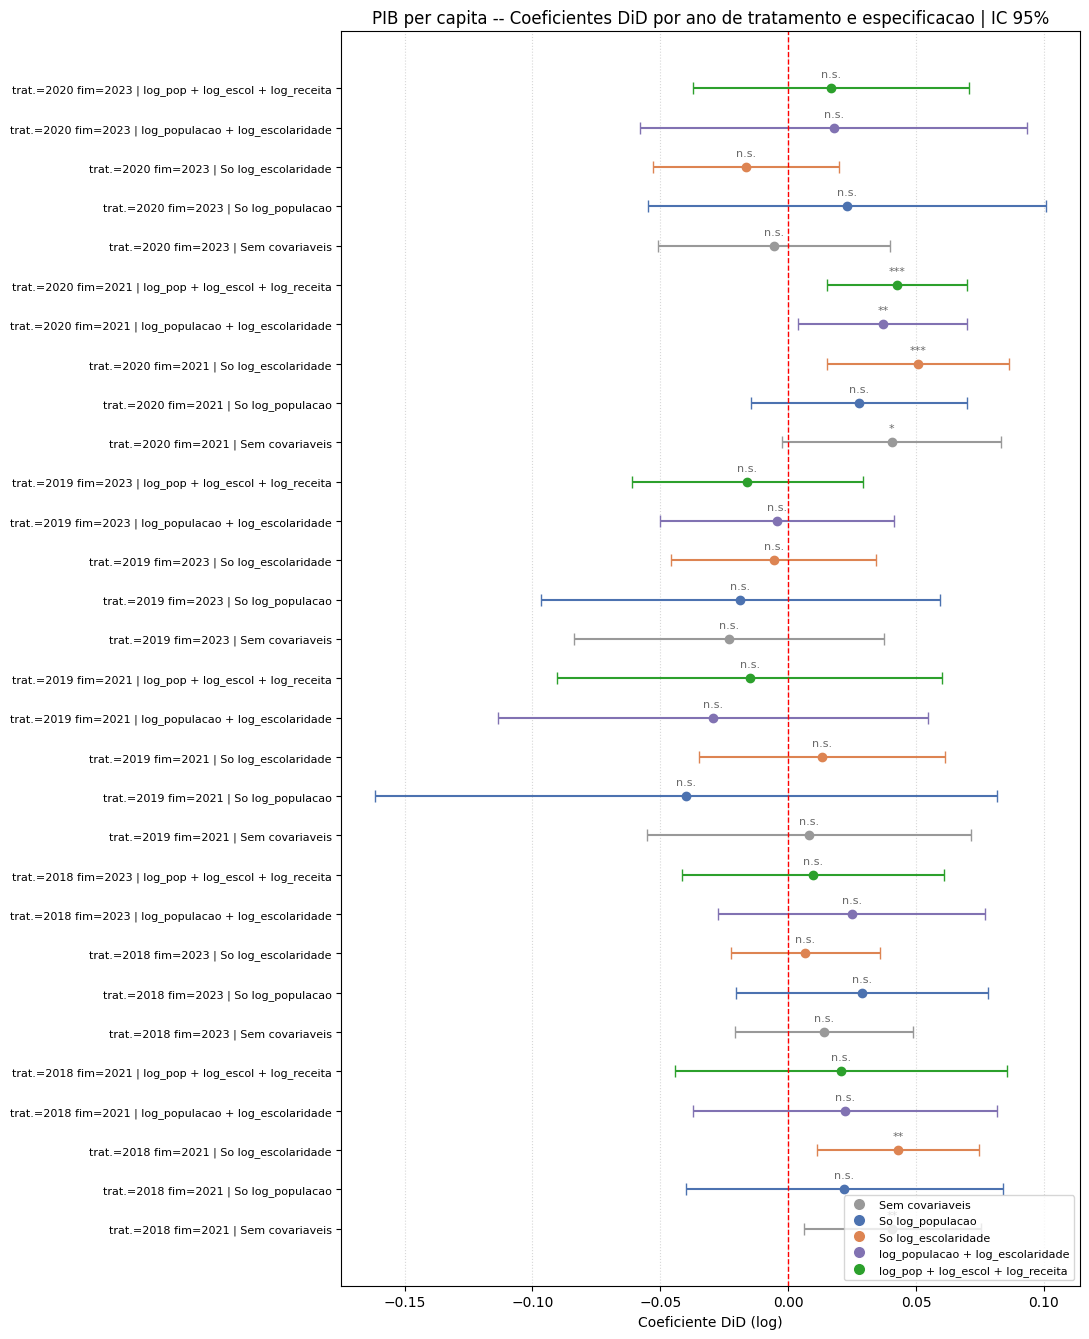

In [80]:
paleta = {
    "Sem covariaveis"                             : "#999999",
    "So log_populacao"                            : "#4C72B0",
    "So log_escolaridade"                         : "#DD8452",
    "log_populacao + log_escolaridade"            : "#8172B2",
    "log_pop + log_escol + log_receita"           : "#2CA02C",
}

sub = df_resultados_pib.copy().reset_index(drop=True)

sub["eixo_y"] = (
    "trat.=" + sub["Ano trat."].astype(str)
    + " fim=" + sub["Ano fim"].astype(str)
    + " | " + sub["Covariaveis"]
)

fig, ax = plt.subplots(figsize=(11, max(5, len(sub) * 0.45)))

for i, row in sub.iterrows():
    cor = paleta.get(row["Covariaveis"], "steelblue")
    ax.errorbar(
        row["Coef. DiD"], i,
        xerr=1.96 * row["EP"],
        fmt="o", color=cor, capsize=4, lw=1.5
    )
    ax.text(
        row["Coef. DiD"], i + 0.28,
        row["Sig."], ha="center", fontsize=8, color="dimgray"
    )

ax.axvline(0, color="red", ls="--", lw=1)
ax.set_yticks(range(len(sub)))
ax.set_yticklabels(sub["eixo_y"], fontsize=8)
ax.set_xlabel("Coeficiente DiD (log)")
ax.set_title(f"PIB per capita -- Coeficientes DiD por ano de tratamento e especificacao | IC 95%")
ax.grid(axis="x", ls=":", alpha=0.5)

handles = [Line2D([0],[0], marker="o", color="w", markerfacecolor=c,
                  markersize=9, label=l)
           for l, c in paleta.items()]
ax.legend(handles=handles, fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()


---
## Secao B — PIB de servicos per capita

Estimacao do efeito sobre o PIB do setor de servicos per capita.
Restrito a ano_fim=2021 pela disponibilidade da RAIS.
Sao testados 3 anos de corte pre-tratamento (2017, 2018 e 2019).



######################################################################
  [Servicos] Cenario 01/3 -- log_pib_servicos_per_capita | pre=2017 | trat.=2018 | fim=2021
######################################################################

  Propensity scores:
    Florianopolis (tratado)             PS=0.0484
    -------------------------------------------------------
    Salvador                            PS=0.0449  dist=0.0035
    Rio de Janeiro                      PS=0.0447  dist=0.0037
    Recife                              PS=0.0415  dist=0.0068
    Belo Horizonte                      PS=0.0392  dist=0.0092
    Fortaleza                           PS=0.0280  dist=0.0204
    Goiânia                             PS=0.0263  dist=0.0220
    São José do Rio Preto               PS=0.0723  dist=0.0240

  -- Resultados por especificacao --


,Ano trat.,Coef. DiD,EP,t,p,Sig.,Efeito (%),"IC 2,5%","IC 97,5%",R2,N obs.
Especificacao,,,,,,,,,,,
Sem covariaveis,2018,0.057225,0.023172,2.4696,0.0171,**,5.89,0.010635,0.103815,0.0653,64
So log_populacao,2018,0.044341,0.041606,1.0657,0.2920,n.s.,4.53,-0.039360,0.128042,0.0761,64
So log_escolaridade,2018,0.059512,0.021361,2.7860,0.0077,***,6.13,0.016539,0.102486,0.1730,64
log_populacao + log_escolaridade,2018,0.044498,0.039885,1.1157,0.2704,n.s.,4.55,-0.035785,0.124782,0.1878,64
log_pop + log_escol + log_receita,2018,0.043253,0.041790,1.0350,0.3062,n.s.,4.42,-0.040917,0.127423,0.2060,64


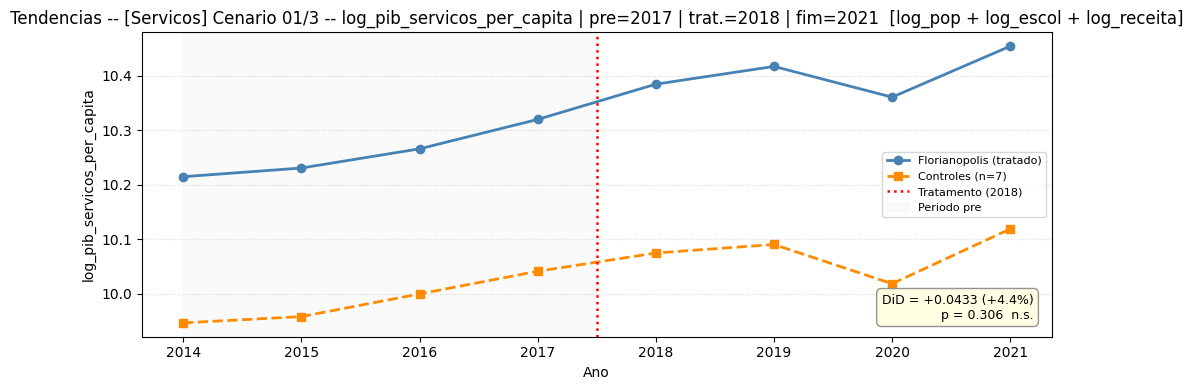

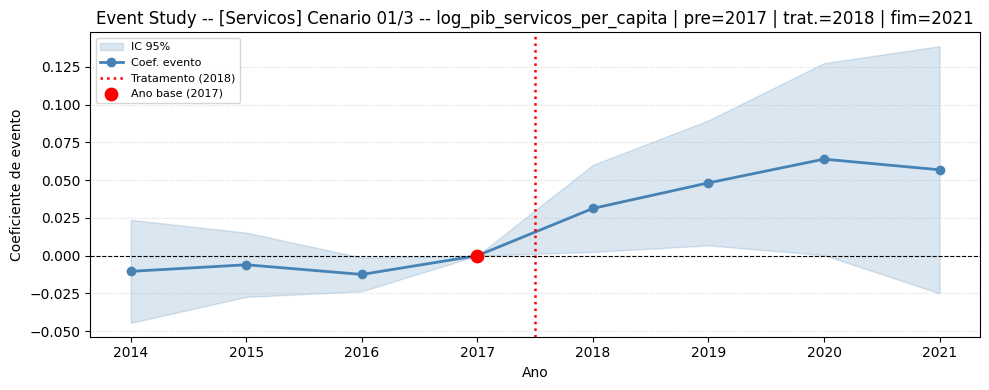


  -- Coeficientes do event study --


,Coef.,EP,p,"IC 2,5%","IC 97,5%",Sig.
Ano,,,,,,
2014,-0.0104,0.0174,0.5539,-0.0445,0.0237,n.s.
2015,-0.0060,0.0109,0.5829,-0.0273,0.0153,n.s.
2016,-0.0124,0.0057,0.0345,-0.0235,-0.0013,**
2017,0.0000,0.0000,NaN,0.0000,0.0000,(base)
2018,0.0313,0.0147,0.0393,0.0025,0.0601,**
2019,0.0482,0.0211,0.0277,0.0068,0.0895,**
2020,0.0639,0.0324,0.0553,0.0004,0.1273,*
2021,0.0568,0.0417,0.1804,-0.0249,0.1386,n.s.



######################################################################
  [Servicos] Cenario 02/3 -- log_pib_servicos_per_capita | pre=2018 | trat.=2019 | fim=2021
######################################################################

  Propensity scores:
    Florianopolis (tratado)             PS=0.0485
    -------------------------------------------------------
    Salvador                            PS=0.0464  dist=0.0021
    Rio de Janeiro                      PS=0.0429  dist=0.0056
    Recife                              PS=0.0390  dist=0.0095
    Belo Horizonte                      PS=0.0380  dist=0.0105
    Fortaleza                           PS=0.0288  dist=0.0197
    São José do Rio Preto               PS=0.0700  dist=0.0215
    Goiânia                             PS=0.0258  dist=0.0227
    Embu das Artes                      PS=0.0250  dist=0.0235

  -- Resultados por especificacao --


,Ano trat.,Coef. DiD,EP,t,p,Sig.,Efeito (%),"IC 2,5%","IC 97,5%",R2,N obs.
Especificacao,,,,,,,,,,,
Sem covariaveis,2019,0.026241,0.039279,0.6681,0.5069,n.s.,2.66,-0.052476,0.104959,0.0042,72
So log_populacao,2019,-0.023184,0.078012,-0.2972,0.7675,n.s.,-2.29,-0.179588,0.133221,0.0724,72
So log_escolaridade,2019,0.032672,0.029939,1.0913,0.2800,n.s.,3.32,-0.027352,0.092696,0.0745,72
log_populacao + log_escolaridade,2019,-0.009046,0.054860,-0.1649,0.8697,n.s.,-0.90,-0.119081,0.100989,0.1185,72
log_pop + log_escol + log_receita,2019,0.007183,0.050057,0.1435,0.8864,n.s.,0.72,-0.093264,0.107630,0.2278,72


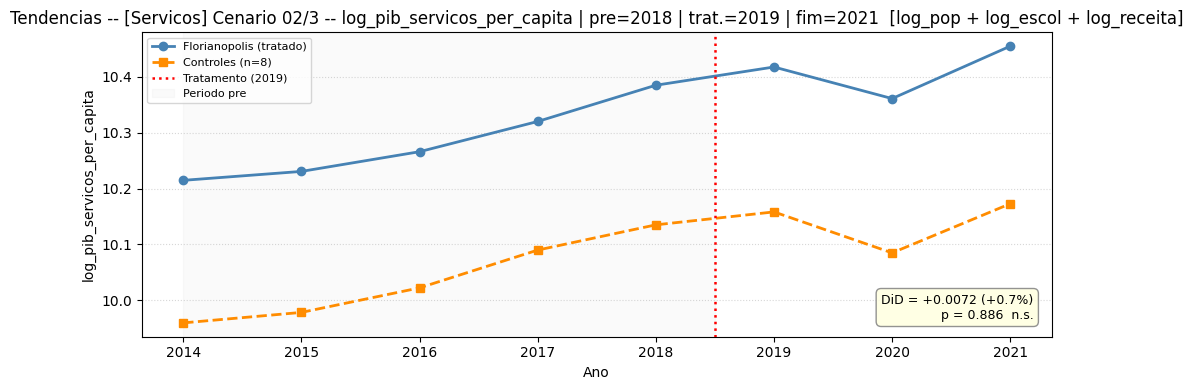

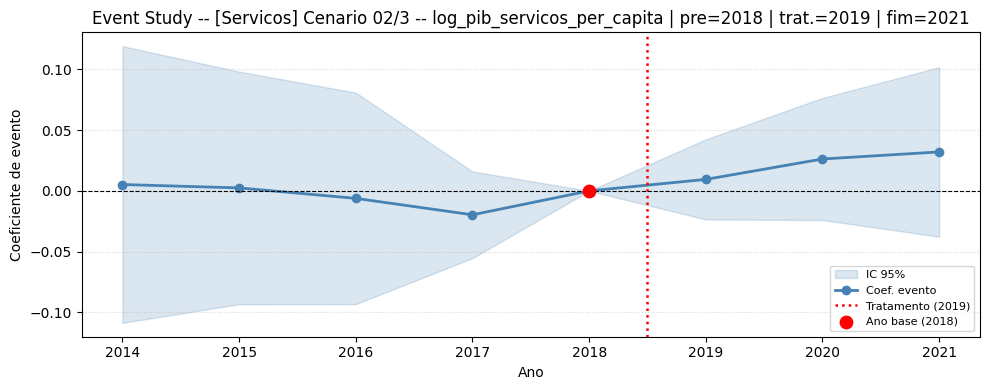


  -- Coeficientes do event study --


,Coef.,EP,p,"IC 2,5%","IC 97,5%",Sig.
Ano,,,,,,
2014,0.0052,0.0581,0.9285,-0.1087,0.1192,n.s.
2015,0.0025,0.0489,0.9600,-0.0933,0.0983,n.s.
2016,-0.0061,0.0444,0.8905,-0.0932,0.0810,n.s.
2017,-0.0197,0.0182,0.2847,-0.0554,0.0160,n.s.
2018,0.0000,0.0000,NaN,0.0000,0.0000,(base)
2019,0.0095,0.0168,0.5763,-0.0235,0.0425,n.s.
2020,0.0263,0.0257,0.3107,-0.0240,0.0766,n.s.
2021,0.0321,0.0356,0.3718,-0.0377,0.1019,n.s.



######################################################################
  [Servicos] Cenario 03/3 -- log_pib_servicos_per_capita | pre=2019 | trat.=2020 | fim=2021
######################################################################

  Propensity scores:
    Florianopolis (tratado)             PS=0.0488
    -------------------------------------------------------
    Salvador                            PS=0.0474  dist=0.0014
    Rio de Janeiro                      PS=0.0409  dist=0.0079
    Recife                              PS=0.0406  dist=0.0082
    Belo Horizonte                      PS=0.0384  dist=0.0104
    Fortaleza                           PS=0.0281  dist=0.0207
    Goiânia                             PS=0.0245  dist=0.0243

  -- Resultados por especificacao --


,Ano trat.,Coef. DiD,EP,t,p,Sig.,Efeito (%),"IC 2,5%","IC 97,5%",R2,N obs.
Especificacao,,,,,,,,,,,
Sem covariaveis,2020,0.070632,0.025455,2.7748,0.0083,***,7.32,0.019225,0.122039,0.1037,56
So log_populacao,2020,0.067796,0.028946,2.3421,0.0242,**,7.01,0.009293,0.126298,0.1044,56
So log_escolaridade,2020,0.083101,0.020976,3.9617,0.0003,***,8.67,0.040706,0.125496,0.3273,56
log_populacao + log_escolaridade,2020,0.079040,0.022907,3.4505,0.0014,***,8.22,0.032707,0.125373,0.3288,56
log_pop + log_escol + log_receita,2020,0.084497,0.019962,4.2329,0.0001,***,8.82,0.044086,0.124908,0.3728,56


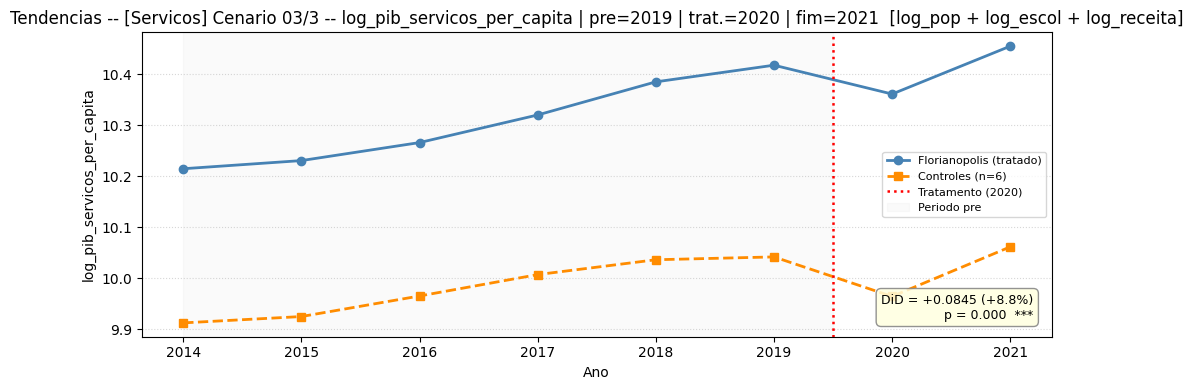

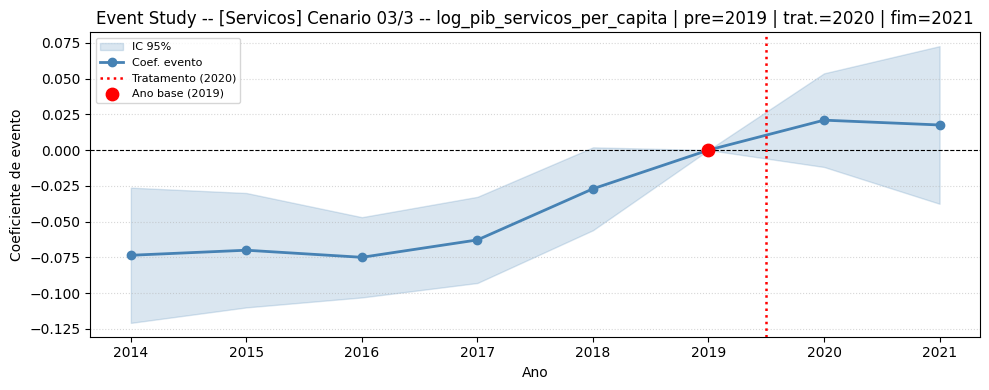


  -- Coeficientes do event study --


,Coef.,EP,p,"IC 2,5%","IC 97,5%",Sig.
Ano,,,,,,
2014,-0.0735,0.0241,0.0043,-0.1208,-0.0263,***
2015,-0.0700,0.0204,0.0016,-0.1100,-0.0300,***
2016,-0.0750,0.0143,0.0000,-0.1030,-0.0469,***
2017,-0.0628,0.0154,0.0002,-0.0929,-0.0327,***
2018,-0.0271,0.0148,0.0757,-0.0560,0.0019,*
2019,0.0000,0.0000,NaN,0.0000,0.0000,(base)
2020,0.0209,0.0167,0.2188,-0.0118,0.0536,n.s.
2021,0.0175,0.0281,0.5365,-0.0375,0.0726,n.s.



Concluido [Servicos] -- 15 modelos (3 cenarios x 5 especificacoes)


In [81]:
resultados_servicos = []
total = len(CENARIOS_SERVICOS)

for cenario, (var_dep, ano_pre, ano_fim) in enumerate(CENARIOS_SERVICOS, start=1):

    ano_tratamento = ano_pre + 1
    rotulo = (
        f"[Servicos] Cenario {cenario:02d}/{total} -- {var_dep} "
        f"| pre={ano_pre} | trat.={ano_tratamento} | fim={ano_fim}"
    )

    print(f"\n{'#'*70}")
    print(f"  {rotulo}")
    print(f"{'#'*70}")

    # -- 1-4: Matching ---------------------------------------------------
    df_m   = preparar_base(df_combinado, df_distancia_filtrado, MUNICIPIO_TRATADO, ano_pre)
    df_avg = construir_covariaveis(df_m, ANO_MATCHING_INICIO, ano_pre, MUNICIPIO_TRATADO)
    df_avg = estimar_propensity_score(df_avg, COVARIAVEIS_MATCHING)
    _, grupo_controle = realizar_matching(df_avg, MUNICIPIO_TRATADO, K_CONTROLES, CALIPER)

    ps_flp = df_avg.loc[df_avg["id_municipio"] == MUNICIPIO_TRATADO, "propensity_score"].iloc[0]
    print("\n  Propensity scores:")
    print(f"    {'Florianopolis (tratado)':<35} PS={ps_flp:.4f}")
    print(f"    {'-'*55}")
    for _, r in grupo_controle[["municipio", "propensity_score", "distancia_ps"]].iterrows():
        print(f"    {r['municipio']:<35} PS={r['propensity_score']:.4f}  dist={r['distancia_ps']:.4f}")

    # -- 5: Amostra DiD --------------------------------------------------
    df_did, _ = construir_amostra_did(
        df_m, MUNICIPIO_TRATADO, grupo_controle,
        ano_pre, ANO_MATCHING_INICIO, ano_fim
    )

    if var_dep not in df_did.columns:
        print(f"  {var_dep} ausente no painel -- cenario ignorado")
        continue

    # -- 6: Loop de especificacoes DiD -----------------------------------
    res_por_spec = {}

    for rotulo_spec, covs in ESPECIFICACOES_DID:
        try:
            res, _ = estimar_did(df_did, var_dep, covs)
            res_por_spec[rotulo_spec] = res
            resultados_servicos.append(consolidar_resultado(
                var_dep, ano_pre, ano_fim, rotulo_spec, grupo_controle, res
            ))
        except Exception as e:
            print(f"  [{rotulo_spec}] Erro: {e}")

    # -- Tabela comparativa das especificacoes deste cenario -------------
    linhas_cen = [
        r for r in resultados_servicos
        if r["var_dep"] == var_dep
        and r["ano_pre"] == ano_pre
        and r["ano_fim"] == ano_fim
    ]
    if linhas_cen:
        print("\n  -- Resultados por especificacao --")
        display(
            pd.DataFrame(linhas_cen)
            .rename(columns={
                "covariaveis" : "Especificacao",
                "ano_pre"     : "Ano pre",
                "coef_did"    : "Coef. DiD",
                "erro_padrao" : "EP",
                "t_stat"      : "t",
                "p_valor"     : "p",
                "efeito_pct"  : "Efeito (%)",
                "r2_within"   : "R2",
                "sig"         : "Sig.",
                "n_obs"       : "N obs.",
                "ic_25"       : "IC 2,5%",
                "ic_975"      : "IC 97,5%",
            })
            .assign(**{"Ano trat.": ano_tratamento})
            [["Ano trat.", "Especificacao", "Coef. DiD", "EP", "t", "p", "Sig.",
              "Efeito (%)", "IC 2,5%", "IC 97,5%", "R2", "N obs."]]
            .set_index("Especificacao")
        )

    # -- Graficos: usa ultima especificacao bem-sucedida -----------------
    rotulo_graf = [r for r, _ in ESPECIFICACOES_DID if r in res_por_spec]
    if rotulo_graf:
        res_graf = res_por_spec[rotulo_graf[-1]]
        coef_g   = float(res_graf.params["did"])
        pval_g   = float(res_graf.pvalues["did"])
        plot_tendencias(
            df_did, var_dep, ano_tratamento, len(grupo_controle),
            coef_g, pval_g,
            f"Tendencias -- {rotulo}  [{rotulo_graf[-1]}]"
        )
        df_evento = plot_event_study(
            df_did, var_dep, ano_tratamento,
            f"Event Study -- {rotulo}"
        )
        if df_evento is not None:
            print("\n  -- Coeficientes do event study --")
            display(
                df_evento
                .rename(columns={
                    "ano"     : "Ano",
                    "coef"    : "Coef.",
                    "se"      : "EP",
                    "p_valor" : "p",
                    "ic_low"  : "IC 2,5%",
                    "ic_high" : "IC 97,5%",
                    "sig"     : "Sig.",
                })
                .drop(columns=["ano_base"])
                .set_index("Ano")
                .round(4)
            )

print(f"\nConcluido [Servicos] -- {len(resultados_servicos)} modelos ({total} cenarios x {len(ESPECIFICACOES_DID)} especificacoes)")


#### Tabela consolidada — PIB de servicos per capita


In [82]:
df_resultados_servicos = (
    pd.DataFrame(resultados_servicos)
    .assign(**{"Ano trat.": lambda d: d["ano_pre"] + 1})
    .rename(columns={
        "var_dep"      : "Var. dependente",
        "ano_pre"      : "Ano pre",
        "ano_fim"      : "Ano fim",
        "covariaveis"  : "Covariaveis",
        "n_controles"  : "N contr.",
        "n_obs"        : "N obs.",
        "coef_did"     : "Coef. DiD",
        "erro_padrao"  : "EP",
        "t_stat"       : "t",
        "p_valor"      : "p-valor",
        "ic_25"        : "IC 2,5%",
        "ic_975"       : "IC 97,5%",
        "efeito_pct"   : "Efeito (%)",
        "r2_within"    : "R2 within",
        "sig"          : "Sig.",
    })
)

print("Secao B -- TWFE com EF municipio + ano. Erros clusterizados por municipio.")
print("      * p<0.10  ** p<0.05  *** p<0.01\n")
df_resultados_servicos


Secao B -- TWFE com EF municipio + ano. Erros clusterizados por municipio.
      * p<0.10  ** p<0.05  *** p<0.01



,Var. dependente,Ano pre,Ano fim,Covariaveis,N contr.,N obs.,Coef. DiD,EP,t,p-valor,"IC 2,5%","IC 97,5%",Efeito (%),R2 within,Sig.,Ano trat.
0,log_pib_servicos_per_capita,2017,2021,Sem covariaveis,7,64,0.057225,0.023172,2.4696,0.0171,0.010635,0.103815,5.89,0.0653,**,2018
1,log_pib_servicos_per_capita,2017,2021,So log_populacao,7,64,0.044341,0.041606,1.0657,0.2920,-0.039360,0.128042,4.53,0.0761,n.s.,2018
2,log_pib_servicos_per_capita,2017,2021,So log_escolaridade,7,64,0.059512,0.021361,2.7860,0.0077,0.016539,0.102486,6.13,0.1730,***,2018
3,log_pib_servicos_per_capita,2017,2021,log_populacao + log_escolaridade,7,64,0.044498,0.039885,1.1157,0.2704,-0.035785,0.124782,4.55,0.1878,n.s.,2018
4,log_pib_servicos_per_capita,2017,2021,log_pop + log_escol + log_receita,7,64,0.043253,0.041790,1.0350,0.3062,-0.040917,0.127423,4.42,0.2060,n.s.,2018
5,log_pib_servicos_per_capita,2018,2021,Sem covariaveis,8,72,0.026241,0.039279,0.6681,0.5069,-0.052476,0.104959,2.66,0.0042,n.s.,2019
6,log_pib_servicos_per_capita,2018,2021,So log_populacao,8,72,-0.023184,0.078012,-0.2972,0.7675,-0.179588,0.133221,-2.29,0.0724,n.s.,2019
7,log_pib_servicos_per_capita,2018,2021,So log_escolaridade,8,72,0.032672,0.029939,1.0913,0.2800,-0.027352,0.092696,3.32,0.0745,n.s.,2019
8,log_pib_servicos_per_capita,2018,2021,log_populacao + log_escolaridade,8,72,-0.009046,0.054860,-0.1649,0.8697,-0.119081,0.100989,-0.90,0.1185,n.s.,2019
9,log_pib_servicos_per_capita,2018,2021,log_pop + log_escol + log_receita,8,72,0.007183,0.050057,0.1435,0.8864,-0.093264,0.107630,0.72,0.2278,n.s.,2019


#### Grafico de coeficientes — PIB de servicos per capita


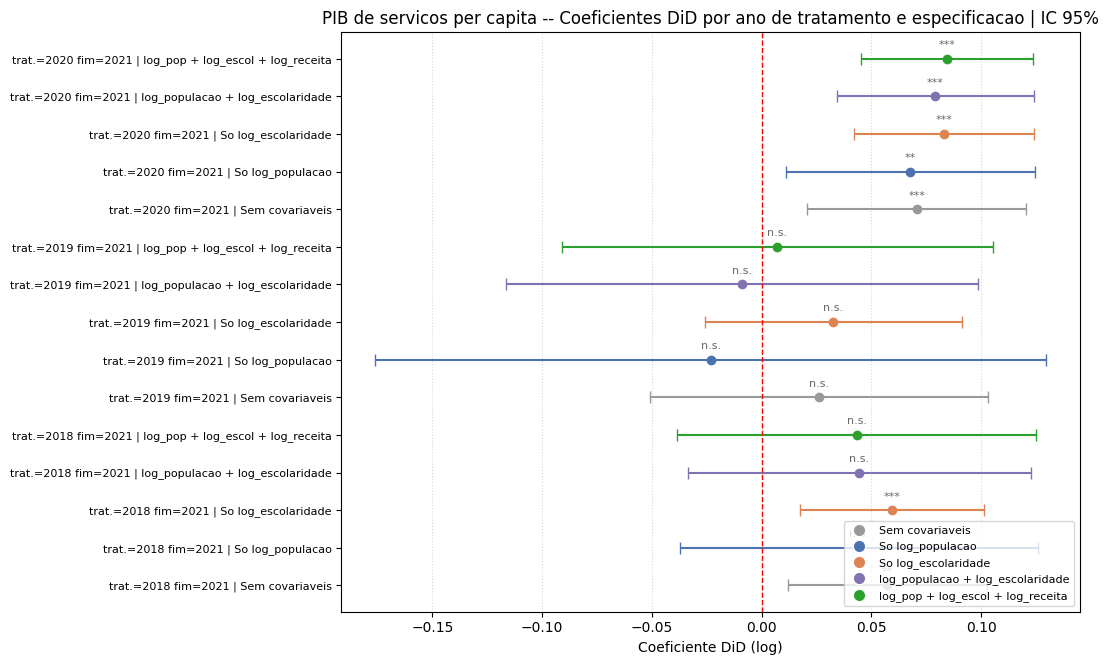

In [83]:
paleta = {
    "Sem covariaveis"                             : "#999999",
    "So log_populacao"                            : "#4C72B0",
    "So log_escolaridade"                         : "#DD8452",
    "log_populacao + log_escolaridade"            : "#8172B2",
    "log_pop + log_escol + log_receita"           : "#2CA02C",
}

sub = df_resultados_servicos.copy().reset_index(drop=True)

sub["eixo_y"] = (
    "trat.=" + sub["Ano trat."].astype(str)
    + " fim=" + sub["Ano fim"].astype(str)
    + " | " + sub["Covariaveis"]
)

fig, ax = plt.subplots(figsize=(11, max(5, len(sub) * 0.45)))

for i, row in sub.iterrows():
    cor = paleta.get(row["Covariaveis"], "steelblue")
    ax.errorbar(
        row["Coef. DiD"], i,
        xerr=1.96 * row["EP"],
        fmt="o", color=cor, capsize=4, lw=1.5
    )
    ax.text(
        row["Coef. DiD"], i + 0.28,
        row["Sig."], ha="center", fontsize=8, color="dimgray"
    )

ax.axvline(0, color="red", ls="--", lw=1)
ax.set_yticks(range(len(sub)))
ax.set_yticklabels(sub["eixo_y"], fontsize=8)
ax.set_xlabel("Coeficiente DiD (log)")
ax.set_title(f"PIB de servicos per capita -- Coeficientes DiD por ano de tratamento e especificacao | IC 95%")
ax.grid(axis="x", ls=":", alpha=0.5)

handles = [Line2D([0],[0], marker="o", color="w", markerfacecolor=c,
                  markersize=9, label=l)
           for l, c in paleta.items()]
ax.legend(handles=handles, fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()
